In [31]:
## Plot the results from the BNNs on one graph
from __future__ import annotations

import argparse
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import precision_recall_curve, average_precision_score

try:
    from sklearn.metrics import confusion_matrix
except ImportError as exc:  # pragma: no cover
    raise SystemExit("This script needs scikit-learn: pip install scikit-learn") from exc

In [57]:
plt.rcParams['font.size'] = 24

df = pd.read_csv('echonext_metadata_100k.csv')
le = LabelEncoder()
SHD = le.fit_transform(df['shd_moderate_or_greater_flag'].values.reshape(-1,1))
id    = le.fit_transform(df['split'].values.reshape(-1,1))
id_test  = np.where(id!=2)
n_test=2000
ytest = SHD[id_test][:n_test]


c:\Users\mjcol\miniconda3\envs\ML\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\mjcol\miniconda3\envs\ML\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [73]:
def load_npz(path: Path) -> dict[str, np.ndarray]:
    with np.load(path, allow_pickle=True) as data:
        return {key: data[key] for key in data.files}
    

# NN_results_3_ECG = load_npz('outputs/NN_roc_results_3_ECG_10neuron_70000train_20000test.npz')
# NN_results_3_ECG2 = load_npz('outputs/NN_roc_results_3_ECG_ECHO_10neuron_70000train_20000test.npz')
# NN_results_3_Echo = load_npz('outputs/NN_roc_results_3_ALLDATA_10neuron_70000train_20000test.npz')

# NN_results_5_ECG = load_npz('outputs/NN_roc_results_5_ECG_20neuron_70000train_20000test_dropout50.npz')
# NN_results_5_ECG2 = load_npz('outputs/NN_roc_results_5_ECG_ECHO_20neuron_70000train_20000test_dropout50.npz')
# NN_results_5_Echo = load_npz('outputs/NN_roc_results_5_ALLDATA_20neuron_70000train_20000test_dropout50.npz')

# NN_results_10_ECG = load_npz('outputs/NN_roc_results_10_ECG_20neuron_70000train_20000test_dropout50.npz')
# NN_results_10_ECG2 = load_npz('outputs/NN_roc_results_10_ECG_ECHO_20neuron_70000train_20000test_dropout50.npz')
# NN_results_10_Echo = load_npz('outputs/NN_roc_results_10_ALLDATA_20neuron_70000train_20000test_dropout50.npz')


NN_results_3_ECG = load_npz('outputs/NN_roc_results_3_ECG_10neuron_8000train_2000test_dropout20_TANH.npz')
NN_results_3_ECG2 = load_npz('outputs/NN_roc_results_3_ECG_ECHO_10neuron_8000train_2000test_dropout20_TANH.npz')
NN_results_3_Echo = load_npz('outputs/NN_roc_results_3_ALLDATA_10neuron_8000train_2000test_dropout20_TANH.npz')

NN_results_5_ECG = load_npz('outputs/NN_roc_results_5_ECG_20neuron_8000train_2000test_dropout50_TANH.npz')
NN_results_5_ECG2 = load_npz('outputs/NN_roc_results_5_ECG_ECHO_20neuron_8000train_2000test_dropout50_TANH.npz')
NN_results_5_Echo = load_npz('outputs/NN_roc_results_5_ALLDATA_20neuron_8000train_2000test_dropout50_TANH.npz')

NN_results_10_ECG = load_npz('outputs/NN_roc_results_10_ECG_20neuron_8000train_2000test_dropout50_TANH.npz')
NN_results_10_ECG2 = load_npz('outputs/NN_roc_results_10_ECG_ECHO_20neuron_8000train_2000test_dropout50_TANH.npz')
NN_results_10_Echo = load_npz('outputs/NN_roc_results_10_ALLDATA_20neuron_8000train_2000test_dropout50_TANH.npz')




In [74]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from typing import Callable
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    auc,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)


def predict_fn_single(
    X_np: np.ndarray,
    model: nn.Module,
    device: str = "cpu",
) -> np.ndarray:
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)

    with torch.no_grad():
        logits = model(X_t)
        probs = F.softmax(logits, dim=1)[:, 1]

    return probs.cpu().numpy()


def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))


def _interp_roc_on_grid(
    fpr: np.ndarray,
    tpr: np.ndarray,
    fpr_grid: np.ndarray,
) -> np.ndarray:
    """
    Interpolate a ROC curve onto a fixed FPR grid.

    Handles duplicate FPR values by keeping the maximum TPR at each FPR.
    """
    fpr = np.asarray(fpr)
    tpr = np.asarray(tpr)

    unique_fpr = np.unique(fpr)

    max_tpr = np.array([
        np.max(tpr[fpr == u]) for u in unique_fpr
    ])

    tpr_grid = np.interp(fpr_grid, unique_fpr, max_tpr)

    # Enforce ROC boundary behavior
    tpr_grid[0] = 0.0
    tpr_grid[-1] = 1.0

    return tpr_grid


def evaluate_model_with_bootstrap_roc_ci(
    predict_fn: Callable,
    X: np.ndarray,
    y_true: np.ndarray,
    site: str = "probs",
    n_bootstraps: int = 2000,
    threshold: float = 0.5,
    fpr_grid: np.ndarray | None = None,
    ci: tuple[float, float] = (2.5, 97.5),
    random_state: int = 0,
    stratified: bool = True,
    plot: bool = True,
    plot_sample_rocs: int = 40,
    predict_kwargs: dict | None = None,
) -> dict:
    """
    Evaluate a fixed trained model and construct bootstrap confidence intervals
    for the ROC curve and AUC.

    Parameters
    ----------
    predict_fn:
        Function returning probabilities or logits for class 1.
        Example:
            lambda X_in: predict_fn_single(X_in, model, device="cuda")

    X:
        Evaluation features.

    y_true:
        Binary labels, shape (n_samples,).

    site:
        "probs" if predict_fn returns probabilities.
        "logits" if predict_fn returns logits for class 1.

    n_bootstraps:
        Number of bootstrap resamples.

    stratified:
        If True, resample positives and negatives separately so every bootstrap
        sample contains both classes.

    Returns
    -------
    Dictionary containing:
        auc_mean, auc_ci, auc_samples,
        fpr_grid, tpr_mean, tpr_lower, tpr_upper, tpr_samples,
        probs_mean, y_pred, confusion_matrix,
        roc_fpr, roc_tpr, roc_thresholds,
        probs_samples
    """

    rng = np.random.default_rng(random_state)

    X = np.asarray(X)
    y_true = np.asarray(y_true).astype(int)

    if fpr_grid is None:
        fpr_grid = np.linspace(0.0, 1.0, 201)

    predict_kwargs = predict_kwargs or {}

    raw = np.asarray(predict_fn(X, **predict_kwargs))

    if raw.ndim == 2 and raw.shape[1] == 1:
        raw = raw.reshape(-1)

    if site == "probs":
        probs = raw.astype(float)
    elif site == "logits":
        probs = sigmoid(raw.astype(float))
    else:
        raise ValueError("site must be either 'probs' or 'logits'")

    if probs.shape[0] != y_true.shape[0]:
        raise ValueError("probs and y_true must have the same length.")

    n_obs = len(y_true)

    # ROC from original, non-resampled evaluation data
    roc_fpr, roc_tpr, roc_thresholds = roc_curve(y_true, probs)
    roc_auc_val = roc_auc_score(y_true, probs)

    tpr_samples_grid = np.zeros((n_bootstraps, len(fpr_grid)), dtype=float)
    auc_samples = np.zeros(n_bootstraps, dtype=float)
    probs_samples = np.zeros((n_bootstraps, n_obs), dtype=float)

    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]

    if len(pos_idx) == 0 or len(neg_idx) == 0:
        raise ValueError("y_true must contain both positive and negative classes.")

    for b in range(n_bootstraps):
        if stratified:
            boot_pos = rng.choice(pos_idx, size=len(pos_idx), replace=True)
            boot_neg = rng.choice(neg_idx, size=len(neg_idx), replace=True)
            boot_idx = np.concatenate([boot_pos, boot_neg])
            rng.shuffle(boot_idx)
        else:
            boot_idx = rng.choice(np.arange(n_obs), size=n_obs, replace=True)

            # Skip pathological bootstrap samples with only one class
            if len(np.unique(y_true[boot_idx])) < 2:
                auc_samples[b] = np.nan
                tpr_samples_grid[b, :] = np.nan
                probs_samples[b, :] = np.nan
                continue

        y_b = y_true[boot_idx]
        probs_b = probs[boot_idx]

        fpr_b, tpr_b, _ = roc_curve(y_b, probs_b)

        auc_samples[b] = roc_auc_score(y_b, probs_b)
        tpr_samples_grid[b, :] = _interp_roc_on_grid(fpr_b, tpr_b, fpr_grid)

        # Store bootstrap probabilities in original-length format.
        # This is mostly for inspection; ROC should use the boot_idx pairs above.
        probs_samples[b, :] = np.nan
        probs_samples[b, boot_idx] = probs_b

    valid = ~np.isnan(auc_samples)
    auc_samples_valid = auc_samples[valid]
    tpr_samples_valid = tpr_samples_grid[valid]

    lower_pct, upper_pct = ci

    tpr_mean = np.nanmean(tpr_samples_valid, axis=0)
    tpr_lower = np.nanpercentile(tpr_samples_valid, lower_pct, axis=0)
    tpr_upper = np.nanpercentile(tpr_samples_valid, upper_pct, axis=0)

    auc_mean = float(np.nanmean(auc_samples_valid))
    auc_ci = (
        float(np.nanpercentile(auc_samples_valid, lower_pct)),
        float(np.nanpercentile(auc_samples_valid, upper_pct)),
    )

    probs_mean = probs.copy()
    y_pred = (probs_mean >= threshold).astype(int)
    confmat = confusion_matrix(y_true, y_pred)

    print(f"ROC AUC: {roc_auc_val:.4f}")
    print(
        f"Bootstrap AUC mean: {auc_mean:.4f}, "
        f"{lower_pct}/{upper_pct}% CI = ({auc_ci[0]:.4f}, {auc_ci[1]:.4f})"
    )
    print(f"\nClassification report, threshold = {threshold}:\n")
    print(classification_report(y_true, y_pred, digits=4))

    if plot:
        plt.figure(figsize=(8, 4))

        plt.subplot(1, 2, 1)

        to_plot = min(plot_sample_rocs, tpr_samples_valid.shape[0])
        sample_idxs = rng.choice(
            np.arange(tpr_samples_valid.shape[0]),
            size=to_plot,
            replace=False,
        )

        for si in sample_idxs:
            plt.plot(
                fpr_grid,
                tpr_samples_valid[si],
                color="gray",
                alpha=0.15,
                linewidth=0.8,
            )

        plt.plot(
            fpr_grid,
            tpr_mean,
            lw=2,
            label=f"Bootstrap mean ROC, AUC={auc_mean:.3f}",
        )

        plt.fill_between(
            fpr_grid,
            tpr_lower,
            tpr_upper,
            alpha=0.25,
            label=f"{lower_pct}/{upper_pct}% bootstrap band",
        )

        plt.plot(
            roc_fpr,
            roc_tpr,
            linestyle="--",
            lw=1.5,
            label=f"Original ROC, AUC={roc_auc_val:.3f}",
        )

        plt.plot([0, 1], [0, 1], "--", color="black", linewidth=0.8)

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC curve with bootstrap confidence band")
        plt.legend(loc="lower right")
        plt.grid(True)

        plt.subplot(1, 2, 2)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=confmat,
            display_labels=[0, 1],
        )
        disp.plot(ax=plt.gca(), cmap=None, colorbar=True)
        plt.title(f"Confusion matrix, threshold={threshold}")

        plt.tight_layout()
        plt.show()

    return {
        "auc_mean": auc_mean,
        "auc_ci": auc_ci,
        "auc_samples": auc_samples_valid,
        "fpr_grid": fpr_grid,
        "tpr_mean": tpr_mean,
        "tpr_lower": tpr_lower,
        "tpr_upper": tpr_upper,
        "tpr_samples": tpr_samples_valid,
        "probs_mean": probs_mean,
        "y_pred": y_pred,
        "confusion_matrix": confmat,
        "roc_fpr": roc_fpr,
        "roc_tpr": roc_tpr,
        "roc_thresholds": roc_thresholds,
        "probs_samples": probs_samples,
    }

def bootstrap_roc_ci_from_probs(
    y_true: np.ndarray,
    probs: np.ndarray,
    n_bootstraps: int = 2000,
    threshold: float = 0.5,
    fpr_grid: np.ndarray | None = None,
    ci: tuple[float, float] = (2.5, 97.5),
    random_state: int = 0,
    stratified: bool = True,
    plot: bool = True,
) -> dict:
    return evaluate_model_with_bootstrap_roc_ci(
        predict_fn=lambda X_dummy: probs,
        X=np.zeros((len(probs), 1)),
        y_true=y_true,
        site="probs",
        n_bootstraps=n_bootstraps,
        threshold=threshold,
        fpr_grid=fpr_grid,
        ci=ci,
        random_state=random_state,
        stratified=stratified,
        plot=plot,
    )

ROC AUC: 0.7357
Bootstrap AUC mean: 0.7352, 2.5/97.5% CI = (0.7114, 0.7577)

Classification report, threshold = 0.5:

              precision    recall  f1-score   support

           0     0.7672    0.6543    0.7063      1209
           1     0.5686    0.6966    0.6261       791

    accuracy                         0.6710      2000
   macro avg     0.6679    0.6754    0.6662      2000
weighted avg     0.6887    0.6710    0.6746      2000



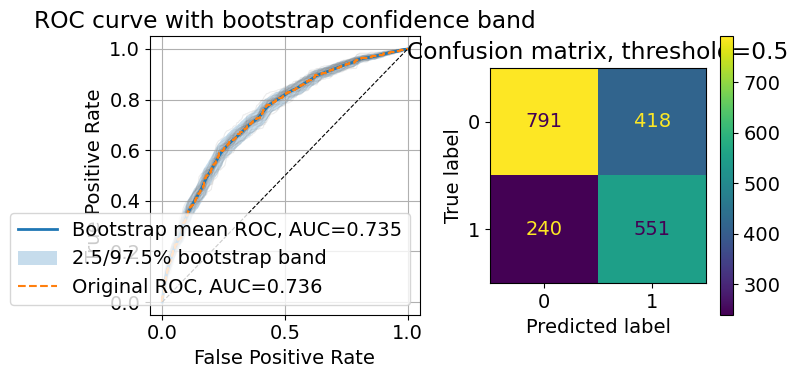

ROC AUC: 0.7300
Bootstrap AUC mean: 0.7294, 2.5/97.5% CI = (0.7056, 0.7518)

Classification report, threshold = 0.5:

              precision    recall  f1-score   support

           0     0.7795    0.5732    0.6606      1209
           1     0.5356    0.7522    0.6257       791

    accuracy                         0.6440      2000
   macro avg     0.6575    0.6627    0.6431      2000
weighted avg     0.6830    0.6440    0.6468      2000



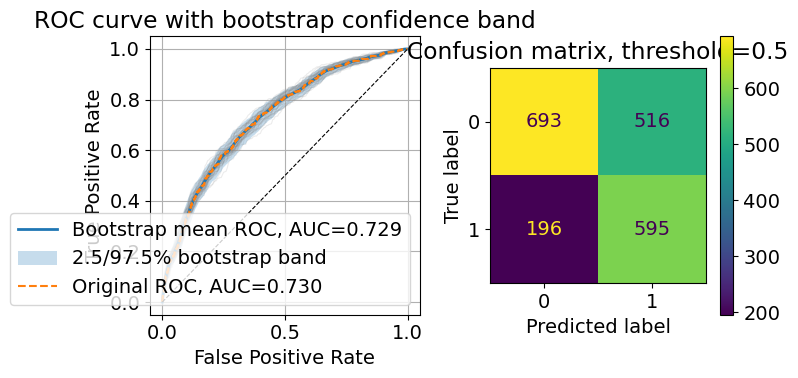

ROC AUC: 0.7314
Bootstrap AUC mean: 0.7306, 2.5/97.5% CI = (0.7064, 0.7534)

Classification report, threshold = 0.5:

              precision    recall  f1-score   support

           0     0.7493    0.6873    0.7170      1209
           1     0.5758    0.6485    0.6100       791

    accuracy                         0.6720      2000
   macro avg     0.6625    0.6679    0.6635      2000
weighted avg     0.6807    0.6720    0.6747      2000



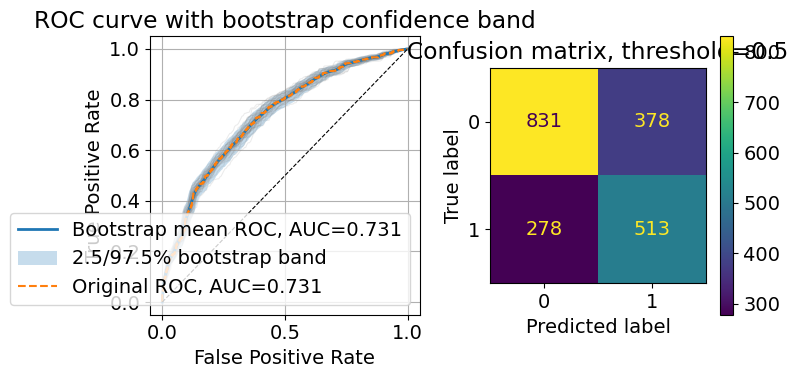

In [75]:
NN_results_3_ECG = bootstrap_roc_ci_from_probs(
    y_true=ytest,
    probs=NN_results_3_ECG['probs_mean'],
    n_bootstraps=500,
    threshold=0.5,
    random_state=42,
)
NN_results_5_ECG = bootstrap_roc_ci_from_probs(
    y_true=ytest,
    probs=NN_results_5_ECG['probs_mean'],
    n_bootstraps=500,
    threshold=0.5,
    random_state=42,
)
NN_results_10_ECG = bootstrap_roc_ci_from_probs(
    y_true=ytest,
    probs=NN_results_10_ECG['probs_mean'],
    n_bootstraps=500,
    threshold=0.5,
    random_state=42,
)

ROC AUC: 0.8654
Bootstrap AUC mean: 0.8642, 2.5/97.5% CI = (0.8476, 0.8801)

Classification report, threshold = 0.5:

              precision    recall  f1-score   support

           0     0.8238    0.8470    0.8352      1209
           1     0.7556    0.7231    0.7390       791

    accuracy                         0.7980      2000
   macro avg     0.7897    0.7851    0.7871      2000
weighted avg     0.7968    0.7980    0.7972      2000



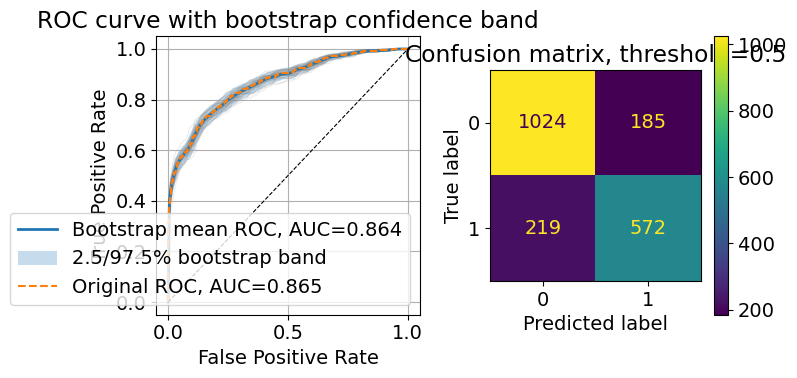

ROC AUC: 0.8538
Bootstrap AUC mean: 0.8525, 2.5/97.5% CI = (0.8342, 0.8696)

Classification report, threshold = 0.5:

              precision    recall  f1-score   support

           0     0.8131    0.8346    0.8237      1209
           1     0.7365    0.7067    0.7213       791

    accuracy                         0.7840      2000
   macro avg     0.7748    0.7706    0.7725      2000
weighted avg     0.7828    0.7840    0.7832      2000



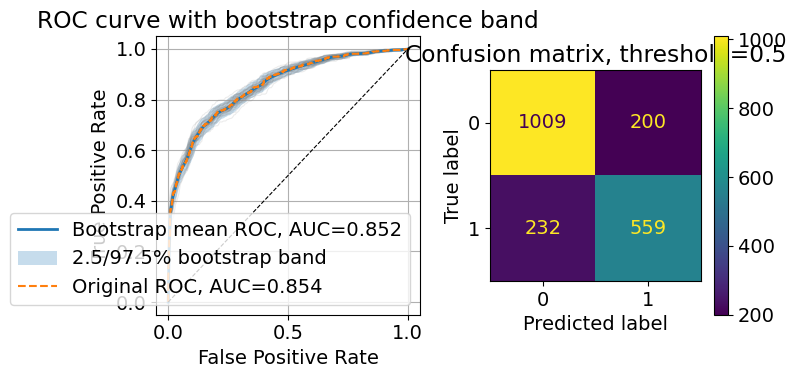

ROC AUC: 0.7586
Bootstrap AUC mean: 0.7583, 2.5/97.5% CI = (0.7380, 0.7773)

Classification report, threshold = 0.5:

              precision    recall  f1-score   support

           0     0.8045    0.7899    0.7972      1209
           1     0.6876    0.7067    0.6970       791

    accuracy                         0.7570      2000
   macro avg     0.7461    0.7483    0.7471      2000
weighted avg     0.7583    0.7570    0.7576      2000



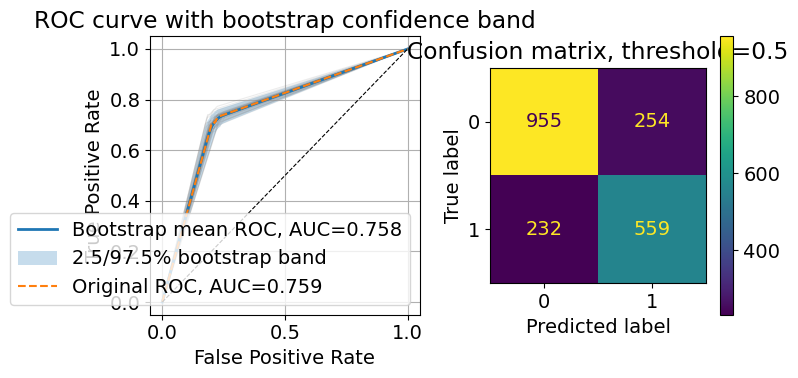

In [76]:
NN_results_3_ECG2 = bootstrap_roc_ci_from_probs(
    y_true=ytest,
    probs=NN_results_3_ECG2['probs_mean'],
    n_bootstraps=500,
    threshold=0.5,
    random_state=42,
)
NN_results_5_ECG2 = bootstrap_roc_ci_from_probs(
    y_true=ytest,
    probs=NN_results_5_ECG2['probs_mean'],
    n_bootstraps=500,
    threshold=0.5,
    random_state=42,
)
NN_results_10_ECG2 = bootstrap_roc_ci_from_probs(
    y_true=ytest,
    probs=NN_results_10_ECG2['probs_mean'],
    n_bootstraps=500,
    threshold=0.5,
    random_state=42,
)

ROC AUC: 0.9233
Bootstrap AUC mean: 0.9234, 2.5/97.5% CI = (0.9092, 0.9354)

Classification report, threshold = 0.5:

              precision    recall  f1-score   support

           0     0.8870    0.9735    0.9282      1209
           1     0.9525    0.8104    0.8757       791

    accuracy                         0.9090      2000
   macro avg     0.9197    0.8919    0.9020      2000
weighted avg     0.9129    0.9090    0.9074      2000



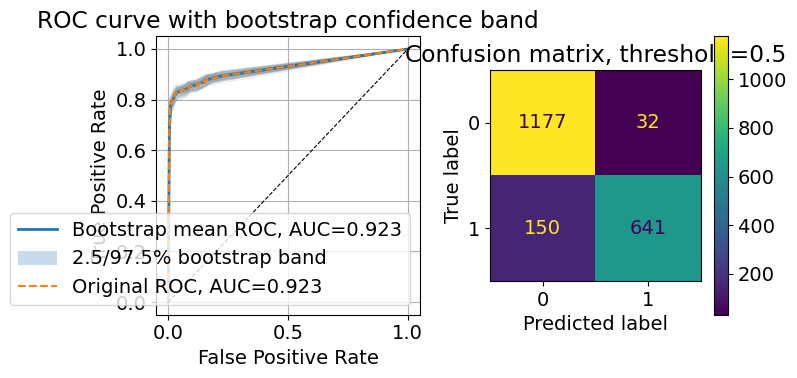

ROC AUC: 0.9234
Bootstrap AUC mean: 0.9235, 2.5/97.5% CI = (0.9091, 0.9364)

Classification report, threshold = 0.5:

              precision    recall  f1-score   support

           0     0.8908    0.9719    0.9296      1209
           1     0.9501    0.8180    0.8791       791

    accuracy                         0.9110      2000
   macro avg     0.9204    0.8949    0.9043      2000
weighted avg     0.9143    0.9110    0.9096      2000



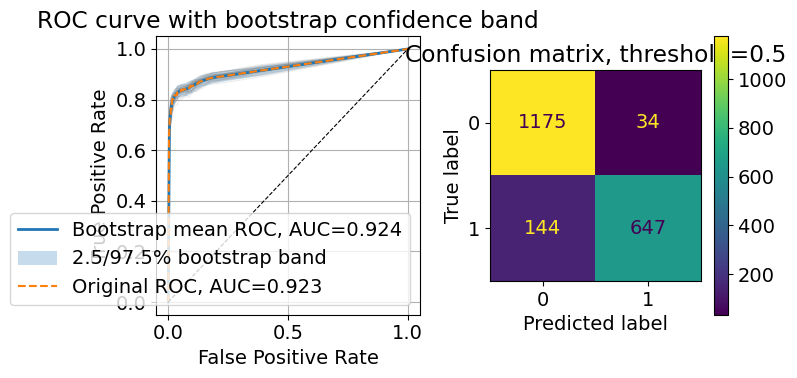

ROC AUC: 0.7992
Bootstrap AUC mean: 0.7986, 2.5/97.5% CI = (0.7805, 0.8168)

Classification report, threshold = 0.5:

              precision    recall  f1-score   support

           0     0.8095    0.9347    0.8676      1209
           1     0.8692    0.6637    0.7527       791

    accuracy                         0.8275      2000
   macro avg     0.8393    0.7992    0.8101      2000
weighted avg     0.8331    0.8275    0.8221      2000



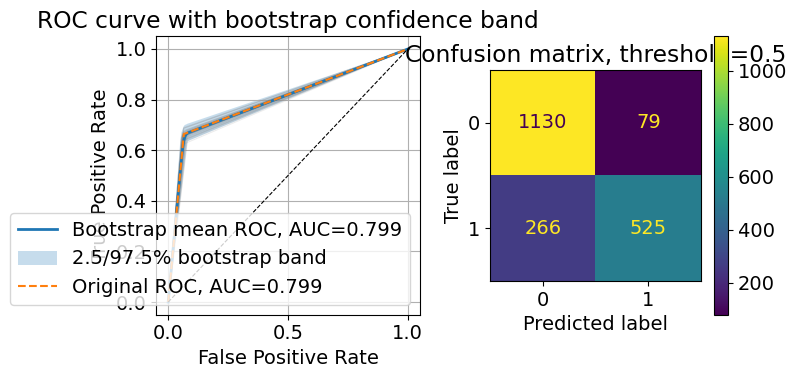

In [77]:
NN_results_3_Echo = bootstrap_roc_ci_from_probs(
    y_true=ytest,
    probs=NN_results_3_Echo['probs_mean'],
    n_bootstraps=500,
    threshold=0.5,
    random_state=42,
)
NN_results_5_Echo = bootstrap_roc_ci_from_probs(
    y_true=ytest,
    probs=NN_results_5_Echo['probs_mean'],
    n_bootstraps=500,
    threshold=0.5,
    random_state=42,
)
NN_results_10_Echo = bootstrap_roc_ci_from_probs(
    y_true=ytest,
    probs=NN_results_10_Echo['probs_mean'],
    n_bootstraps=500,
    threshold=0.5,
    random_state=42,
)

In [78]:

# BNN_results_3_ECG = load_npz('outputs/bnn_vi_roc_results_3_10neuron_ECG_only_70000train_20000test_prior25_RELU.npz')
# BNN_results_3_ECG2 = load_npz('outputs/bnn_vi_roc_results_3_10neuron_ECG_Echo_70000train_20000test_prior25_RELU.npz')
# BNN_results_3_Echo = load_npz('outputs/bnn_vi_roc_results_3_10neuron_full_70000train_20000test_prior25_RELU.npz')

# BNN_results_5_ECG = load_npz('outputs/bnn_vi_roc_results_5_20neuron_ECG_only_70000train_20000test_prior10_RELU.npz')
# BNN_results_5_ECG2 = load_npz('outputs/bnn_vi_roc_results_5_20neuron_ECG_Echo_70000train_20000test_prior10_RELU.npz')
# BNN_results_5_Echo = load_npz('outputs/bnn_vi_roc_results_5_20neuron_full_70000train_20000test_prior10_RELU.npz')


# BNN_results_10_ECG = load_npz('outputs/bnn_vi_roc_results_10_20neuron_ECG_only_70000train_20000test_prior10_RELU.npz')
# BNN_results_10_ECG2 = load_npz('outputs/bnn_vi_roc_results_10_20neuron_ECG_Echo_70000train_20000test_prior10_RELU.npz')
# BNN_results_10_Echo = load_npz('outputs/bnn_vi_roc_results_10_20neuron_full_70000train_20000test_prior10_RELU.npz')


BNN_results_3_ECG = load_npz('outputs/bnn_vi_roc_results_3_10neuron_ECG_only_8000train_2000test_prior25.npz')
BNN_results_3_ECG2 = load_npz('outputs/bnn_vi_roc_results_3_10neuron_ECG_Echo_8000train_2000test_prior25.npz')
BNN_results_3_Echo = load_npz('outputs/bnn_vi_roc_results_3_10neuron_full_8000train_2000test_prior25.npz')

BNN_results_5_ECG = load_npz('outputs/bnn_vi_roc_results_5_20neuron_ECG_only_8000train_2000test_prior10.npz')
BNN_results_5_ECG2 = load_npz('outputs/bnn_vi_roc_results_5_20neuron_ECG_Echo_8000train_2000test_prior10.npz')
BNN_results_5_Echo = load_npz('outputs/bnn_vi_roc_results_5_20neuron_full_8000train_2000test_prior10.npz')


BNN_results_10_ECG = load_npz('outputs/bnn_vi_roc_results_10_20neuron_ECG_only_8000train_2000test_prior10.npz')
BNN_results_10_ECG2 = load_npz('outputs/bnn_vi_roc_results_10_20neuron_ECG_Echo_8000train_2000test_prior10.npz')
BNN_results_10_Echo = load_npz('outputs/bnn_vi_roc_results_10_20neuron_full_8000train_2000test_prior10.npz')



In [79]:
def plot_roc_with_uncertainty(results,ax,Dataname,uqlabel):
    fpr_grid = results.get("fpr_grid")
    tpr_mean = results.get("tpr_mean")
    tpr_lower = results.get("tpr_lower")
    tpr_upper = results.get("tpr_upper")
    tpr_samples = results.get("tpr_samples")
    auc_samples = results.get("auc_samples")
    auc_mean = float(np.asarray(results.get("auc_mean", np.nan)))
    auc_ci = np.asarray(results.get("auc_ci", [np.nan, np.nan])).ravel()

    if fpr_grid is None or tpr_mean is None:
        print(f"[skip]: missing fpr_grid or tpr_mean, cannot plot ROC uncertainty.")
        return


    if tpr_samples is not None and tpr_samples.ndim == 2:
        rng = np.random.default_rng(123)
        n_draw = min(500, tpr_samples.shape[0])
        draw_idx = rng.choice(tpr_samples.shape[0], size=n_draw, replace=False)
        # for idx in draw_idx:
            # ax.plot(fpr_grid, tpr_samples[idx], color="0.65", alpha=0.252, linewidth=0.7)

    if tpr_lower is not None and tpr_upper is not None:
        ax.fill_between(fpr_grid, tpr_lower, tpr_upper, alpha=0.25)

    if uqlabel==1:
        label = f"{Dataname} AUROC={auc_mean:.3f}"
        label += f" [{auc_ci[0]:.3f}, {auc_ci[1]:.3f}]"
    else:
        label = f"{Dataname} AUROC={auc_mean:.3f}"
                
    ax.plot(fpr_grid, tpr_mean, linewidth=2.5,label=label)

    # if "roc_fpr" in results and "roc_tpr" in results:
        # ax.plot(results["roc_fpr"], results["roc_tpr"], linestyle="--", linewidth=1.5)

    
    # # fig.savefig(out_path, dpi=dpi)

    # if auc_samples is not None:
    #     fig2, ax2 = plt.subplots(figsize=(7.5, 4.5))
    #     ax2.hist(auc_samples, bins=30, alpha=0.8)
    #     ax2.axvline(np.mean(auc_samples), linestyle="--", linewidth=2, label=f"Mean={np.mean(auc_samples):.3f}")
    #     if auc_ci.size >= 2:
    #         ax2.axvline(auc_ci[0], linestyle=":", linewidth=2, label=f"Lower={auc_ci[0]:.3f}")
    #         ax2.axvline(auc_ci[1], linestyle=":", linewidth=2, label=f"Upper={auc_ci[1]:.3f}")
    #     ax2.set_xlabel("AUC")
    #     ax2.set_ylabel("Posterior sample count")
    #     ax2.set_title(f"AUC posterior distribution\n{title}")
    #     ax2.legend()
    #     fig2.tight_layout()
    #     fig2.savefig(out_path.with_name(out_path.stem + "_auc_hist.png"), dpi=dpi)

<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
C:\Users\mjcol\AppData\Local\Temp\ipykernel_21948\2573738286.py:12: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"ROC: 3 Layer with 10 neurons, Dropout=0.2 or $\sigma^2$=0.25")


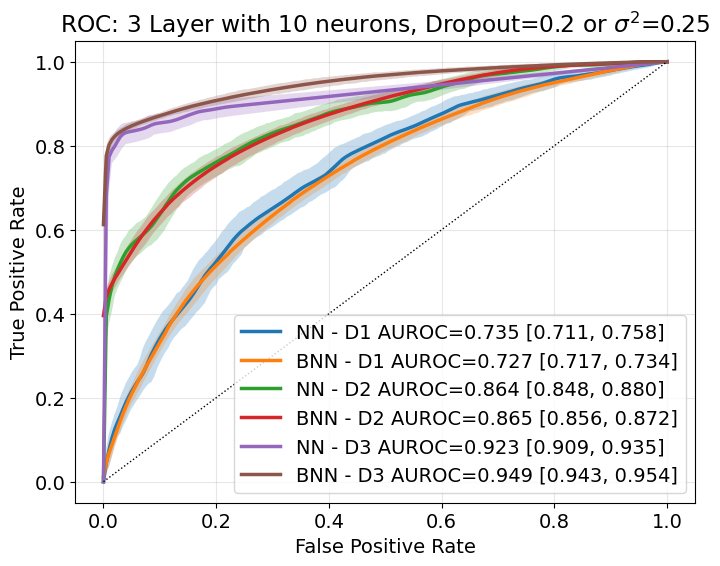

In [80]:
plt.rcParams['font.size'] = 14
fig, ax = plt.subplots(figsize=(8, 6))
plot_roc_with_uncertainty(NN_results_3_ECG,ax,'NN - D1',uqlabel=1)
plot_roc_with_uncertainty(BNN_results_3_ECG,ax,'BNN - D1',uqlabel=1)
plot_roc_with_uncertainty(NN_results_3_ECG2,ax, 'NN - D2',uqlabel=1)
plot_roc_with_uncertainty(BNN_results_3_ECG2,ax, 'BNN - D2',uqlabel=1)
plot_roc_with_uncertainty(NN_results_3_Echo,ax,'NN - D3',uqlabel=1)
plot_roc_with_uncertainty(BNN_results_3_Echo,ax,'BNN - D3',uqlabel=1)
ax.plot([0, 1], [0, 1], linestyle=":", linewidth=1.0, color="k")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC: 3 Layer with 10 neurons, Dropout=0.2 or $\sigma^2$=0.25")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")
# fig.tight_layout()
fig.savefig(f"PaperFigures/ROC_Comparison_3Layer_8k_TANH",dpi=300)




<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
C:\Users\mjcol\AppData\Local\Temp\ipykernel_21948\1721353223.py:12: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"ROC: 5 Layer with 20 neurons, Dropout=0.5 or $\sigma^2$=0.1")


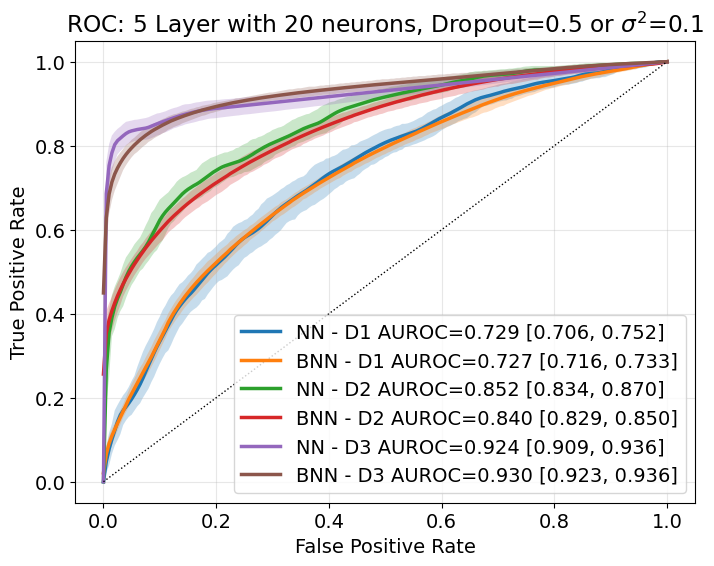

In [81]:
plt.rcParams['font.size'] = 14
fig, ax = plt.subplots(figsize=(8, 6))
plot_roc_with_uncertainty(NN_results_5_ECG,ax,'NN - D1',uqlabel=1)
plot_roc_with_uncertainty(BNN_results_5_ECG,ax,'BNN - D1',uqlabel=1)
plot_roc_with_uncertainty(NN_results_5_ECG2,ax, 'NN - D2',uqlabel=1)
plot_roc_with_uncertainty(BNN_results_5_ECG2,ax, 'BNN - D2',uqlabel=1)
plot_roc_with_uncertainty(NN_results_5_Echo,ax,'NN - D3',uqlabel=1)
plot_roc_with_uncertainty(BNN_results_5_Echo,ax,'BNN - D3',uqlabel=1)
ax.plot([0, 1], [0, 1], linestyle=":", linewidth=1.0, color="k")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC: 5 Layer with 20 neurons, Dropout=0.5 or $\sigma^2$=0.1")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")
# fig.tight_layout()
fig.savefig("PaperFigures/ROC_Comparison_5Layer_8k_TANH",dpi=300)




<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
C:\Users\mjcol\AppData\Local\Temp\ipykernel_21948\1102762486.py:12: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"ROC: 10 Layer with 20 neurons, Dropout=0.5 or $\sigma^2$=0.1")


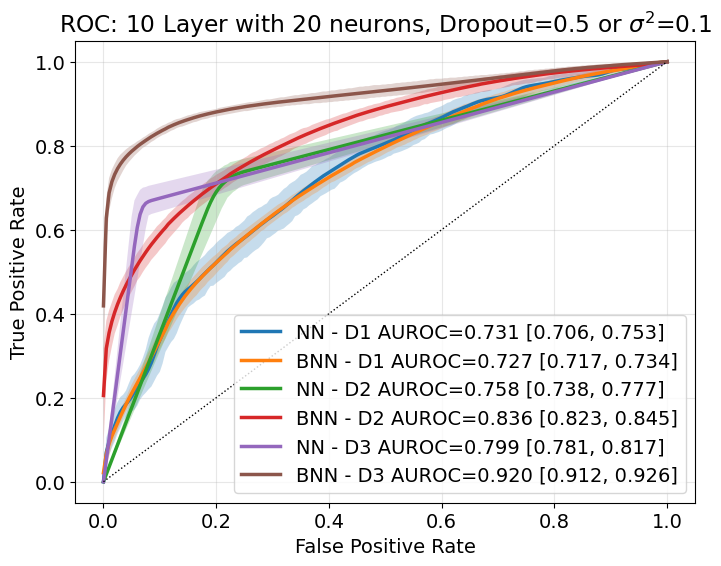

In [82]:
plt.rcParams['font.size'] = 14
fig, ax = plt.subplots(figsize=(8, 6))
plot_roc_with_uncertainty(NN_results_10_ECG,ax,'NN - D1',uqlabel=1)
plot_roc_with_uncertainty(BNN_results_10_ECG,ax,'BNN - D1',uqlabel=1)
plot_roc_with_uncertainty(NN_results_10_ECG2,ax, 'NN - D2',uqlabel=1)
plot_roc_with_uncertainty(BNN_results_10_ECG2,ax, 'BNN - D2',uqlabel=1)
plot_roc_with_uncertainty(NN_results_10_Echo,ax,'NN - D3',uqlabel=1)
plot_roc_with_uncertainty(BNN_results_10_Echo,ax,'BNN - D3',uqlabel=1)
ax.plot([0, 1], [0, 1], linestyle=":", linewidth=1.0, color="k")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC: 10 Layer with 20 neurons, Dropout=0.5 or $\sigma^2$=0.1")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")
# fig.tight_layout()
fig.savefig("PaperFigures/ROC_Comparison_10Layer_8k_TANH",dpi=300)




In [83]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, Tuple

import numpy as np
from sklearn.calibration import calibration_curve
from sklearn.metrics import average_precision_score, brier_score_loss

# ============================================================
# Validation
# ============================================================

def validate_binary_inputs(y_true: np.ndarray, y_prob: np.ndarray) -> None:
    if y_true.ndim != 1:
        raise ValueError("y_true must be 1D.")
    if y_prob.ndim != 1:
        raise ValueError("y_prob must be 1D.")
    if len(y_true) != len(y_prob):
        raise ValueError("y_true and y_prob must have same length.")
    if not np.all(np.isin(y_true, [0, 1])):
        raise ValueError("y_true must contain only 0 and 1.")
    if np.any((y_prob < 0) | (y_prob > 1)):
        raise ValueError("y_prob must lie in [0, 1].")


def validate_bayesian_inputs(y_true: np.ndarray, y_prob_samples: np.ndarray) -> None:
    if y_true.ndim != 1:
        raise ValueError("y_true must be 1D.")
    if y_prob_samples.ndim != 2:
        raise ValueError("y_prob_samples must be 2D with shape (n_samples, n_draws).")
    if len(y_true) != y_prob_samples.shape[0]:
        raise ValueError("y_true and y_prob_samples must agree in n_samples.")
    if not np.all(np.isin(y_true, [0, 1])):
        raise ValueError("y_true must contain only 0 and 1.")
    if np.any((y_prob_samples < 0) | (y_prob_samples > 1)):
        raise ValueError("All posterior predictive probabilities must lie in [0, 1].")


# ============================================================
# Frequentist-style metrics using sklearn
# ============================================================

def compute_auprc_sklearn(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    validate_binary_inputs(y_true, y_prob)
    return float(average_precision_score(y_true, y_prob))


def compute_brier_sklearn(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    validate_binary_inputs(y_true, y_prob)
    return float(brier_score_loss(y_true, y_prob))


def compute_calibration_curve_sklearn(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    n_bins: int = 10,
    strategy: str = "uniform",
) -> Dict[str, np.ndarray]:
    """
    Returns calibration curve points using sklearn.calibration.calibration_curve.

    Outputs:
        prob_true: observed fraction of positives in each non-empty bin
        prob_pred: mean predicted probability in each non-empty bin
    """
    validate_binary_inputs(y_true, y_prob)

    prob_true, prob_pred = calibration_curve(
        y_true,
        y_prob,
        n_bins=n_bins,
        strategy=strategy,
    )

    return {
        "prob_true": prob_true,
        "prob_pred": prob_pred,
    }


# ============================================================
# ECE (not built into sklearn)
# ============================================================

def compute_ece(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    n_bins: int = 10,
    strategy: str = "uniform",
) -> Tuple[float, Dict[str, np.ndarray]]:
    """
    Expected Calibration Error for binary classification.

    This is not built into sklearn, so we compute it directly.
    """
    validate_binary_inputs(y_true, y_prob)

    if strategy not in {"uniform", "quantile"}:
        raise ValueError("strategy must be 'uniform' or 'quantile'.")

    n = len(y_true)

    if strategy == "uniform":
        bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    else:
        bin_edges = np.quantile(y_prob, np.linspace(0.0, 1.0, n_bins + 1))
        bin_edges[0] = 0.0
        bin_edges[-1] = 1.0
        bin_edges = np.maximum.accumulate(bin_edges)

    bin_counts = np.zeros(n_bins, dtype=int)
    bin_acc = np.full(n_bins, np.nan)
    bin_conf = np.full(n_bins, np.nan)

    ece = 0.0

    for b in range(n_bins):
        left = bin_edges[b]
        right = bin_edges[b + 1]

        if b == n_bins - 1:
            mask = (y_prob >= left) & (y_prob <= right)
        else:
            mask = (y_prob >= left) & (y_prob < right)

        count = int(np.sum(mask))
        bin_counts[b] = count

        if count > 0:
            acc = np.mean(y_true[mask])
            conf = np.mean(y_prob[mask])
            bin_acc[b] = acc
            bin_conf[b] = conf
            ece += (count / n) * abs(acc - conf)

    details = {
        "bin_edges": bin_edges,
        "bin_counts": bin_counts,
        "bin_accuracy": bin_acc,
        "bin_confidence": bin_conf,
    }

    return float(ece), details


# ============================================================
# Bayesian summaries
# ============================================================

def predictive_mean(y_prob_samples: np.ndarray) -> np.ndarray:
    return np.mean(y_prob_samples, axis=1)


def predictive_variance(y_prob_samples: np.ndarray) -> np.ndarray:
    return np.var(y_prob_samples, axis=1, ddof=1)


def predictive_entropy(y_prob: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    p = np.clip(y_prob, eps, 1.0 - eps)
    return -(p * np.log(p) + (1.0 - p) * np.log(1.0 - p))


# ============================================================
# Coverage-risk curve (custom; not in sklearn)
# ============================================================

def hard_predictions(y_prob: np.ndarray, threshold: float = 0.5) -> np.ndarray:
    return (y_prob >= threshold).astype(int)


def compute_coverage_risk_curve(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    uncertainty: np.ndarray,
    threshold: float = 0.5,
    n_points: int = 50,
) -> Dict[str, np.ndarray]:
    """
    Sort by increasing uncertainty, then compute risk on retained least-uncertain cases.
    """
    validate_binary_inputs(y_true, y_prob)

    if uncertainty.ndim != 1 or len(uncertainty) != len(y_true):
        raise ValueError("uncertainty must be 1D with same length as y_true.")

    n = len(y_true)
    order = np.argsort(uncertainty)  # least uncertain first

    y_true_sorted = y_true[order]
    y_pred_sorted = hard_predictions(y_prob[order], threshold=threshold)
    unc_sorted = uncertainty[order]

    coverages = np.linspace(1.0 / n, 1.0, min(n_points, n))
    risks = np.zeros_like(coverages)
    retained = np.zeros_like(coverages, dtype=int)
    uncertainty_threshold = np.zeros_like(coverages)

    cumulative_errors = np.cumsum((y_pred_sorted != y_true_sorted).astype(float))

    for i, c in enumerate(coverages):
        k = max(1, int(np.floor(c * n)))
        retained[i] = k
        risks[i] = cumulative_errors[k - 1] / k
        uncertainty_threshold[i] = unc_sorted[k - 1]

    return {
        "coverage": coverages,
        "risk": risks,
        "retained_count": retained,
        "uncertainty_threshold": uncertainty_threshold,
    }


# ============================================================
# Dataclasses
# ============================================================

@dataclass
class FrequentistMetrics:
    auprc: float
    brier_score: float
    ece: float
    calibration: Dict[str, np.ndarray]
    ece_details: Dict[str, np.ndarray]
    coverage_risk: Dict[str, np.ndarray]


@dataclass
class BayesianMetrics:
    auprc: float
    brier_score: float
    ece: float
    calibration: Dict[str, np.ndarray]
    ece_details: Dict[str, np.ndarray]
    coverage_risk_variance: Dict[str, np.ndarray]
    coverage_risk_entropy: Dict[str, np.ndarray]
    mean_prob: np.ndarray
    variance: np.ndarray
    entropy: np.ndarray


# ============================================================
# Evaluation wrappers
# ============================================================

def evaluate_frequentist_model(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    n_bins: int = 10,
    calibration_strategy: str = "uniform",
    threshold: float = 0.5,
    n_coverage_points: int = 50,
) -> FrequentistMetrics:
    """
    Frequentist NN:
      - use y_prob directly
      - uncertainty proxy = min(p, 1-p)
    """
    validate_binary_inputs(y_true, y_prob)

    auprc = compute_auprc_sklearn(y_true, y_prob)
    brier = compute_brier_sklearn(y_true, y_prob)
    calibration = compute_calibration_curve_sklearn(
        y_true, y_prob, n_bins=n_bins, strategy=calibration_strategy
    )
    ece, ece_details = compute_ece(
        y_true, y_prob, n_bins=n_bins, strategy=calibration_strategy
    )

    # Confidence-based uncertainty proxy
    uncertainty = np.minimum(y_prob, 1.0 - y_prob)

    coverage_risk = compute_coverage_risk_curve(
        y_true=y_true,
        y_prob=y_prob,
        uncertainty=uncertainty,
        threshold=threshold,
        n_points=n_coverage_points,
    )

    return FrequentistMetrics(
        auprc=auprc,
        brier_score=brier,
        ece=ece,
        calibration=calibration,
        ece_details=ece_details,
        coverage_risk=coverage_risk,
    )


def evaluate_bayesian_model(
    y_true: np.ndarray,
    y_prob_samples: np.ndarray,
    n_bins: int = 10,
    calibration_strategy: str = "uniform",
    threshold: float = 0.5,
    n_coverage_points: int = 50,
) -> BayesianMetrics:
    """
    Bayesian NN:
      - compute posterior predictive mean probability
      - compute variance and entropy as uncertainty summaries
    """
    validate_bayesian_inputs(y_true, y_prob_samples)

    mean_prob = predictive_mean(y_prob_samples)
    variance = predictive_variance(y_prob_samples)
    entropy = predictive_entropy(mean_prob)

    auprc = compute_auprc_sklearn(y_true, mean_prob)
    brier = compute_brier_sklearn(y_true, mean_prob)
    calibration = compute_calibration_curve_sklearn(
        y_true, mean_prob, n_bins=n_bins, strategy=calibration_strategy
    )
    ece, ece_details = compute_ece(
        y_true, mean_prob, n_bins=n_bins, strategy=calibration_strategy
    )

    coverage_risk_variance = compute_coverage_risk_curve(
        y_true=y_true,
        y_prob=mean_prob,
        uncertainty=variance,
        threshold=threshold,
        n_points=n_coverage_points,
    )

    coverage_risk_entropy = compute_coverage_risk_curve(
        y_true=y_true,
        y_prob=mean_prob,
        uncertainty=entropy,
        threshold=threshold,
        n_points=n_coverage_points,
    )

    return BayesianMetrics(
        auprc=auprc,
        brier_score=brier,
        ece=ece,
        calibration=calibration,
        ece_details=ece_details,
        coverage_risk_variance=coverage_risk_variance,
        coverage_risk_entropy=coverage_risk_entropy,
        mean_prob=mean_prob,
        variance=variance,
        entropy=entropy,
    )

In [84]:
def plot_pr_curves_freq_bootstrap_from_probs(
    y_true,
    y_prob_freq,
    freq_label="Frequentist NN",
    title="Precision-Recall Curve",
    plt=None,
    plot_prev=False,
    ci_level=0.95,
    recall_grid_size=200,
    ci_alpha=0.25,
    n_bootstraps=500,
    random_state=0,
    stratified=True,
    ax=None,
):
    """
    Bootstrap PR confidence intervals directly from one fixed vector of
    frequentist predicted probabilities.
    """

    if plt is None:
        import matplotlib.pyplot as plt

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))

    rng = np.random.default_rng(random_state)

    y_true = np.asarray(y_true).astype(int)
    y_prob_freq = np.asarray(y_prob_freq, dtype=float)

    if y_true.ndim != 1:
        raise ValueError("y_true must be 1D.")

    if y_prob_freq.ndim != 1 or len(y_prob_freq) != len(y_true):
        raise ValueError("y_prob_freq must be shape (n_samples,).")

    if not np.all(np.isin(y_true, [0, 1])):
        raise ValueError("y_true must contain only 0 and 1.")

    n_samples = len(y_true)
    prevalence = np.mean(y_true)

    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]

    recall_grid = np.linspace(0, 1, recall_grid_size)

    precision_boot = np.empty((n_bootstraps, recall_grid_size))
    auprc_boot = np.empty(n_bootstraps)

    for b in range(n_bootstraps):
        if stratified:
            boot_pos = rng.choice(pos_idx, size=len(pos_idx), replace=True)
            boot_neg = rng.choice(neg_idx, size=len(neg_idx), replace=True)
            boot_idx = np.concatenate([boot_pos, boot_neg])
            rng.shuffle(boot_idx)
        else:
            boot_idx = rng.choice(np.arange(n_samples), size=n_samples, replace=True)

            if len(np.unique(y_true[boot_idx])) < 2:
                precision_boot[b, :] = np.nan
                auprc_boot[b] = np.nan
                continue

        y_b = y_true[boot_idx]
        prob_b = y_prob_freq[boot_idx]

        precision_b, recall_b, _ = precision_recall_curve(y_b, prob_b)
        auprc_boot[b] = average_precision_score(y_b, prob_b)

        recall_inc = recall_b[::-1]
        precision_inc = precision_b[::-1]

        precision_boot[b] = np.interp(
            recall_grid,
            recall_inc,
            precision_inc,
            left=precision_inc[0],
            right=precision_inc[-1],
        )

    alpha = 1 - ci_level
    lower_q = alpha / 2
    upper_q = 1 - alpha / 2

    precision_mean = np.nanmean(precision_boot, axis=0)
    precision_lower = np.nanquantile(precision_boot, lower_q, axis=0)
    precision_upper = np.nanquantile(precision_boot, upper_q, axis=0)

    auprc_mean = np.nanmean(auprc_boot)
    auprc_lower = np.nanquantile(auprc_boot, lower_q)
    auprc_upper = np.nanquantile(auprc_boot, upper_q)

    ax.plot(
        recall_grid,
        precision_mean,
        linewidth=2,
        label=(
            f"{freq_label} AUPRC = {auprc_mean:.3f} "
            f"[{auprc_lower:.3f}, {auprc_upper:.3f}]"
        ),
    )

    ax.fill_between(
        recall_grid,
        precision_lower,
        precision_upper,
        alpha=ci_alpha,
    )

    if plot_prev:
        ax.axhline(
            y=prevalence,
            linestyle="--",
            linewidth=1.5,
            label=f"Prevalence baseline = {prevalence:.3f}",
        )

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.grid(True)
    ax.legend(loc="best")

    return {
        "recall_grid": recall_grid,
        "precision_mean": precision_mean,
        "precision_lower": precision_lower,
        "precision_upper": precision_upper,
        "precision_samples": precision_boot,
        "auprc_mean": float(auprc_mean),
        "auprc_ci": (float(auprc_lower), float(auprc_upper)),
        "auprc_samples": auprc_boot,
    }

def plot_pr_curves_bayes(
    y_true,
    y_prob_bayes_samples,
    y_prob_freq=None,
    bayes_label="Bayesian NN",
    freq_label="Frequentist NN",
    title="Precision-Recall Curve",
    plt=None,
    plot_prev=False,
    ci_level=0.95,
    recall_grid_size=200,
    ci_alpha=0.25,
    ax=None,
):
    """
    Plot precision-recall curves with credible intervals for Bayesian samples.

    Parameters
    ----------
    y_true : array-like, shape (n_samples,)
        Binary ground-truth labels.

    y_prob_bayes_samples : array-like, shape (n_samples, n_draws)
        Posterior predictive probability samples.

    y_prob_freq : array-like, shape (n_samples,), optional
        Predicted probabilities from a frequentist model.

    bayes_label : str
        Label for Bayesian model in legend.

    freq_label : str
        Label for frequentist model in legend.

    title : str
        Plot title.

    plt : matplotlib.pyplot-like object, optional
        Plotting object. If None, matplotlib.pyplot is used.

    plot_prev : bool
        Whether to plot the prevalence baseline.

    ci_level : float
        Credible interval level, e.g. 0.95 for a 95% credible interval.

    recall_grid_size : int
        Number of points in the common recall grid.

    ci_alpha : float
        Transparency of the credible interval band.
    """
    

    y_true = np.asarray(y_true)

    if y_true.ndim != 1:
        raise ValueError("y_true must be 1D.")

    if not np.all(np.isin(y_true, [0, 1])):
        raise ValueError("y_true must contain only 0 and 1.")

    prevalence = np.mean(y_true)

    # Bayesian samples are now the second argument
    y_prob_bayes_samples = np.asarray(y_prob_bayes_samples)

    if (
        y_prob_bayes_samples.ndim != 2
        or y_prob_bayes_samples.shape[0] != len(y_true)
    ):
        raise ValueError(
            "y_prob_bayes_samples must be shape (n_samples, n_draws)."
        )

    n_draws = y_prob_bayes_samples.shape[1]

    recall_grid = np.linspace(0, 1, recall_grid_size)
    precision_draws = np.empty((n_draws, recall_grid_size))
    auprc_draws = np.empty(n_draws)

    for j in range(n_draws):
        y_prob_draw = y_prob_bayes_samples[:, j]

        precision_j, recall_j, _ = precision_recall_curve(y_true, y_prob_draw)
        auprc_draws[j] = average_precision_score(y_true, y_prob_draw)

        # sklearn returns recall in decreasing order, so reverse for interpolation
        recall_inc = recall_j[::-1]
        precision_inc = precision_j[::-1]

        precision_draws[j] = np.interp(
            recall_grid,
            recall_inc,
            precision_inc,
            left=precision_inc[0],
            right=precision_inc[-1],
        )

    alpha = 1 - ci_level
    lower_q = alpha / 2
    upper_q = 1 - alpha / 2

    precision_lower = np.quantile(precision_draws, lower_q, axis=0)
    precision_upper = np.quantile(precision_draws, upper_q, axis=0)
    precision_mean = np.mean(precision_draws, axis=0)

    auprc_mean = np.mean(auprc_draws)
    auprc_lower = np.quantile(auprc_draws, lower_q)
    auprc_upper = np.quantile(auprc_draws, upper_q)

    ax.plot(
        recall_grid,
        precision_mean,
        linewidth=2,
        label=(
            f"{bayes_label} AUPRC = {auprc_mean:.3f} "
            f"[{auprc_lower:.3f}, {auprc_upper:.3f}]"
        ),
    )

    ax.fill_between(
        recall_grid,
        precision_lower,
        precision_upper,
        alpha=ci_alpha,
    )

    # Optional frequentist curve
    if y_prob_freq is not None:
        y_prob_freq = np.asarray(y_prob_freq)

        if y_prob_freq.ndim != 1 or len(y_prob_freq) != len(y_true):
            raise ValueError("y_prob_freq must be shape (n_samples,).")

        precision_f, recall_f, _ = precision_recall_curve(y_true, y_prob_freq)
        auprc_f = average_precision_score(y_true, y_prob_freq)

        ax.plot(
            recall_f,
            precision_f,
            linewidth=2,
            label=f"{freq_label} AUPRC = {auprc_f:.3f}",
        )

    if plot_prev:
        ax.axhline(
            y=prevalence,
            linestyle="--",
            linewidth=1.5,
            label=f"Prevalence baseline = {prevalence:.3f}",
        )

    

In [45]:
NN_3ECG = evaluate_frequentist_model(y_true=ytest,y_prob=NN_results_3_ECG['probs_mean'],n_bins=10,calibration_strategy='uniform',threshold=0.5,n_coverage_points=50)
NN_3ECG2 = evaluate_frequentist_model(y_true=ytest,y_prob=NN_results_3_ECG2['probs_mean'],n_bins=10,calibration_strategy='uniform',threshold=0.5,n_coverage_points=50)
NN_3Echo = evaluate_frequentist_model(y_true=ytest,y_prob=NN_results_3_Echo['probs_mean'],n_bins=10,calibration_strategy='uniform',threshold=0.5,n_coverage_points=50)

BNN_3Echo = evaluate_bayesian_model(BNN_results_3_Echo['y_true'],BNN_results_3_Echo['probs_samples'][:,:,1].T,n_bins=10,calibration_strategy='uniform',threshold=0.5,n_coverage_points=50)
BNN_ECG2 = evaluate_bayesian_model(BNN_results_3_ECG2['y_true'],BNN_results_3_ECG2['probs_samples'][:,:,1].T,n_bins=10,calibration_strategy='uniform',threshold=0.5,n_coverage_points=50)
BNN_ECG = evaluate_bayesian_model(BNN_results_3_ECG['y_true'],BNN_results_3_ECG['probs_samples'][:,:,1].T,n_bins=10,calibration_strategy='uniform',threshold=0.5,n_coverage_points=50)


C:\Users\mjcol\AppData\Local\Temp\ipykernel_21948\1898497621.py:161: RuntimeWarning: divide by zero encountered in log
  return -(p * np.log(p) + (1.0 - p) * np.log(1.0 - p))
C:\Users\mjcol\AppData\Local\Temp\ipykernel_21948\1898497621.py:161: RuntimeWarning: invalid value encountered in multiply
  return -(p * np.log(p) + (1.0 - p) * np.log(1.0 - p))
C:\Users\mjcol\AppData\Local\Temp\ipykernel_21948\1898497621.py:161: RuntimeWarning: divide by zero encountered in log
  return -(p * np.log(p) + (1.0 - p) * np.log(1.0 - p))
C:\Users\mjcol\AppData\Local\Temp\ipykernel_21948\1898497621.py:161: RuntimeWarning: invalid value encountered in multiply
  return -(p * np.log(p) + (1.0 - p) * np.log(1.0 - p))


<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
C:\Users\mjcol\AppData\Local\Temp\ipykernel_21948\2432612236.py:17: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"PRC:  3 Layer with 10 neurons, Dropout=0.2 or $\sigma^2$=0.25")


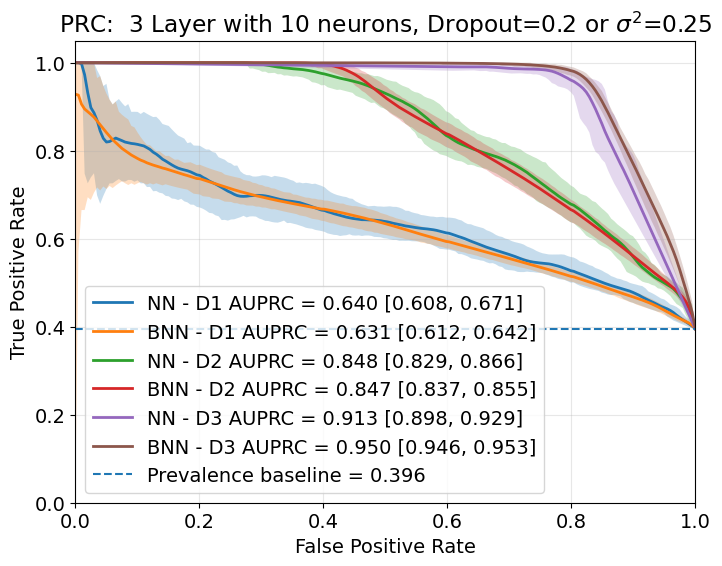

In [85]:


plt.rcParams['font.size'] = 14
fig, ax = plt.subplots(figsize=(8, 6))

plot_pr_curves_freq_bootstrap_from_probs(y_true=ytest,y_prob_freq=NN_results_3_ECG["probs_mean"],freq_label="NN - D1",plot_prev=False,ci_level=0.95,ax=ax)
plot_pr_curves_bayes(y_true=BNN_results_3_ECG['y_true'],y_prob_bayes_samples=BNN_results_3_ECG['probs_samples'][:,:,1].T,plt=plt,bayes_label='BNN - D1',plot_prev=False,ax=ax)


plot_pr_curves_freq_bootstrap_from_probs(y_true=ytest,y_prob_freq=NN_results_3_ECG2["probs_mean"],freq_label="NN - D2",plot_prev=False,ci_level=0.95,ax=ax)
plot_pr_curves_bayes(y_true=BNN_results_3_ECG2['y_true'],y_prob_bayes_samples=BNN_results_3_ECG2['probs_samples'][:,:,1].T,plt=plt,bayes_label='BNN - D2',plot_prev=False,ax=ax)

plot_pr_curves_freq_bootstrap_from_probs(y_true=ytest,y_prob_freq=NN_results_3_Echo['probs_mean'],plt=plt,freq_label='NN - D3',plot_prev=False,ci_level=0.95,ax=ax)
plot_pr_curves_bayes(y_true=BNN_results_3_Echo['y_true'],y_prob_bayes_samples=BNN_results_3_Echo['probs_samples'][:,:,1].T,plt=plt,bayes_label='BNN - D3',plot_prev=True,ax=ax)


ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"PRC:  3 Layer with 10 neurons, Dropout=0.2 or $\sigma^2$=0.25")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower left")
ax.set_xlim([0,1])
ax.set_ylim([0,1.05])

fig.savefig(f"PaperFigures/PRC_Comparison_3Layer_8k_TANH",dpi=300)






<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
C:\Users\mjcol\AppData\Local\Temp\ipykernel_21948\2691381292.py:18: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"PRC:  5 Layer with 20 neurons, Dropout=0.5 or $\sigma^2$=0.1")


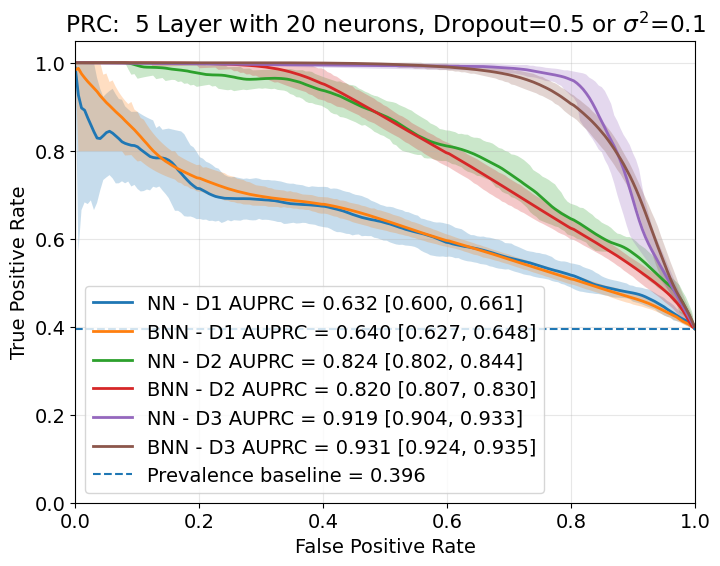

In [86]:
plt.rcParams['font.size'] = 14
fig, ax = plt.subplots(figsize=(8, 6))


plot_pr_curves_freq_bootstrap_from_probs(y_true=ytest,y_prob_freq=NN_results_5_ECG['probs_mean'],plt=plt,freq_label='NN - D1',plot_prev=False,ax=ax,ci_level=0.95)
plot_pr_curves_bayes(y_true=BNN_results_5_ECG['y_true'],y_prob_bayes_samples=BNN_results_5_ECG['probs_samples'][:,:,1].T,plt=plt,bayes_label='BNN - D1',plot_prev=False,ax=ax)


plot_pr_curves_freq_bootstrap_from_probs(y_true=ytest,y_prob_freq=NN_results_5_ECG2['probs_mean'],plt=plt,freq_label='NN - D2',plot_prev=False,ax=ax,ci_level=0.95)
plot_pr_curves_bayes(y_true=BNN_results_5_ECG2['y_true'],y_prob_bayes_samples=BNN_results_5_ECG2['probs_samples'][:,:,1].T,plt=plt,bayes_label='BNN - D2',plot_prev=False,ax=ax)

plot_pr_curves_freq_bootstrap_from_probs(y_true=ytest,y_prob_freq=NN_results_5_Echo['probs_mean'],plt=plt,freq_label='NN - D3',plot_prev=False,ax=ax,ci_level=0.95)
plot_pr_curves_bayes(y_true=BNN_results_5_Echo['y_true'],y_prob_bayes_samples=BNN_results_5_Echo['probs_samples'][:,:,1].T,plt=plt,bayes_label='BNN - D3',plot_prev=True,ax=ax)


ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"PRC:  5 Layer with 20 neurons, Dropout=0.5 or $\sigma^2$=0.1")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower left")
ax.set_xlim([0,1])
ax.set_ylim([0,1.05])

fig.savefig(f"PaperFigures/PRC_Comparison_5Layer_8k_TANH",dpi=300)


<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
C:\Users\mjcol\AppData\Local\Temp\ipykernel_21948\1618873487.py:17: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"PRC:  10 Layer with 20 neurons, Dropout=0.5 or $\sigma^2$=0.1")


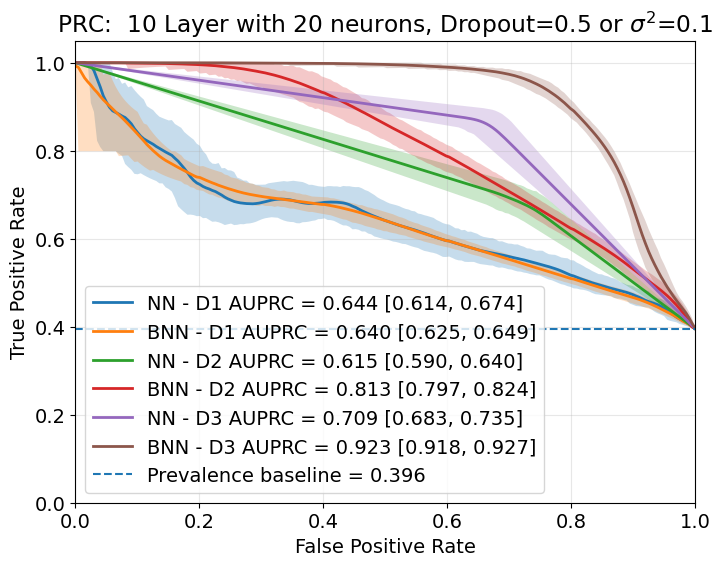

In [87]:
plt.rcParams['font.size'] = 14
fig, ax = plt.subplots(figsize=(8, 6))

plot_pr_curves_freq_bootstrap_from_probs(y_true=ytest,y_prob_freq=NN_results_10_ECG['probs_mean'],plt=plt,freq_label='NN - D1',plot_prev=False,ax=ax,ci_level=0.95)
plot_pr_curves_bayes(y_true=BNN_results_10_ECG['y_true'],y_prob_bayes_samples=BNN_results_10_ECG['probs_samples'][:,:,1].T,plt=plt,bayes_label='BNN - D1',plot_prev=False,ax=ax)


plot_pr_curves_freq_bootstrap_from_probs(y_true=ytest,y_prob_freq=NN_results_10_ECG2['probs_mean'],plt=plt,freq_label='NN - D2',plot_prev=False,ax=ax,ci_level=0.95)
plot_pr_curves_bayes(y_true=BNN_results_10_ECG2['y_true'],y_prob_bayes_samples=BNN_results_10_ECG2['probs_samples'][:,:,1].T,plt=plt,bayes_label='BNN - D2',plot_prev=False,ax=ax)

plot_pr_curves_freq_bootstrap_from_probs(y_true=ytest,y_prob_freq=NN_results_10_Echo['probs_mean'],plt=plt,freq_label='NN - D3',plot_prev=False,ax=ax,ci_level=0.95)
plot_pr_curves_bayes(y_true=BNN_results_10_Echo['y_true'],y_prob_bayes_samples=BNN_results_10_Echo['probs_samples'][:,:,1].T,plt=plt,bayes_label='BNN - D3',plot_prev=True,ax=ax)


ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"PRC:  10 Layer with 20 neurons, Dropout=0.5 or $\sigma^2$=0.1")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower left")
ax.set_xlim([0,1])
ax.set_ylim([0,1.05])

fig.savefig(f"PaperFigures/PRC_Comparison_10Layer_8k_TANH",dpi=300)


In [49]:
fart

NameError: name 'fart' is not defined

In [ ]:
def normalize_probs(probs: np.ndarray) -> np.ndarray:
    """Return posterior probabilities as shape (S,N,K), or mean probs as (N,K)."""
    probs = np.asarray(probs)

    if probs.ndim == 1:
        return np.column_stack([1.0 - probs, probs])

    if probs.ndim == 2:
        # Ambiguous: either (S,N) binary posterior samples or (N,K) mean probs.
        # Caller decides by context. Here, if columns sum roughly to 1, treat as (N,K).
        row_sums = probs.sum(axis=1)
        if probs.shape[1] > 2 and np.allclose(row_sums, 1.0, atol=1e-3):
            return probs
        if probs.shape[1] == 2 and np.allclose(row_sums, 1.0, atol=1e-3):
            return probs
        # Otherwise binary posterior samples (S,N).
        return np.stack([1.0 - probs, probs], axis=-1)

    if probs.ndim == 3:
        if probs.shape[-1] == 1:
            p = probs[..., 0]
            return np.stack([1.0 - p, p], axis=-1)
        return probs

    raise ValueError(f"Expected probability array with ndim 1, 2, or 3; got shape {probs.shape}")

# Look at posterior probabilities for random test cases
def plot_random_class_probabilities_bayesian(
    results: dict[str, np.ndarray],
    posterior_probs: np.ndarray | None,
    num_classes: int,
    title: str,
    out_path: Path,
    dpi: int,
    n_random: int,
    seed: int,
) -> None:
    """
    Plot posterior PDFs of class probabilities for random test samples.

    For binary classification, each selected test sample gets its own plot with
    two PDFs: one for class 0 probability and one for class 1 probability.

    For multiclass classification, each selected test sample gets its own plot
    with one PDF per class.

    The plot title includes the true class when results contains y_true, y_test,
    true_class, true_classes, or labels.
    """

    decision_out = ['accept BNN pred','inconclusive']
    if posterior_probs is None:
        print(
            f"[skip] {title}: posterior probability samples were not saved. "
            "Need probs_samples with shape (S, N, K) to plot PDFs."
        )
        return

    p = normalize_probs(posterior_probs)

    if p.ndim != 3:
        print(f"[skip] {title}: posterior_probs could not be interpreted as shape (S,N,K).")
        return

    true_labels = None
    for key in ("y_true", "y_test", "true_class", "true_classes", "labels"):
        if key in results:
            true_labels = np.asarray(results[key])
            break

    n_samples, n_obs, inferred_num_classes = p.shape

    if true_labels is not None and len(true_labels) != n_obs:
        print(
            f"[warning] {title}: found true labels with length {len(true_labels)}, "
            f"but posterior_probs has N={n_obs}. Not using true labels in titles."
        )
        true_labels = None

    if inferred_num_classes != num_classes:
        print(
            f"[warning] {title}: num_classes={num_classes}, "
            f"but posterior_probs has K={inferred_num_classes}. Using K={inferred_num_classes}."
        )
        num_classes = inferred_num_classes

    rng = np.random.default_rng(seed)
    chosen = rng.choice(n_obs, size=min(n_random, n_obs), replace=False)
    
    class_ids = np.arange(num_classes)
    for obs_idx in chosen:
        decision_plot = decision_out[0]
        BNN_pred = 0
        fig, ax = plt.subplots(figsize=(6, 4))
        for k in class_ids:
            vals = np.asarray(p[:, obs_idx, k], dtype=float)
            vals = vals[np.isfinite(vals)]

            if vals.size < 2:
                continue

            ax.hist(
                vals,
                bins=30,
                density=True,
                alpha=0.35,
                label=f"Class {k}",
            )

            mean_k = np.mean(vals)
            if (mean_k>=0.5):
                BNN_pred=k

            var_k  = np.var(vals)
            ci_low, ci_high = np.percentile(vals, [2.5, 97.5])

            # if ci_high < ci_noSHD_thresh:
            #     # confidently class 0
            #     conf_mat[ytest[i], 0] += 1
            # elif ci_low >= ci_SHD_thresh:
            #     # confidently class 1
            #     conf_mat[ytest[i], 2] += 1
            # else:
            #     # interval crosses 0.5
            #     conf_mat[ytest[i], 1] += 1

            if (k==1) & (ci_high<=0.30):
                decision_plot = decision_out[0]
                BNN_pred=0
            elif (k==1) & (ci_low>=0.50):
                decision_plot = decision_out[0]
                BNN_pred=1
            elif (k==1):
                decision_plot = decision_out[1]


            print(f"sample {obs_idx} class {k} has ci_high={ci_high} and ci_low={ci_low}")
                

            coeff_var = mean_k/np.sqrt(var_k)

            ax.axvline(mean_k, linestyle="--", linewidth=1.5)
            ax.axvline(ci_low, linestyle=":", linewidth=1.0)
            ax.axvline(ci_high, linestyle=":", linewidth=1.0)

        if true_labels is not None:
            true_class_text = f"True class: {true_labels[obs_idx]}"
        else:
            true_class_text = "True class: unavailable"

        entropy = predictive_entropy(np.asarray(p[:, obs_idx, 1].T, dtype=float))
        ax.set_xlim(0, 1)
        ax.set_xlabel("Class probability")
        ax.set_ylabel("Posterior density")
        ax.set_title(
            f"Posterior PDFs of class probabilities\n"
            f"{title}\n"
            f"Test sample {obs_idx} | {true_class_text}\n"
            f"Pred: {BNN_pred} | Decision: {decision_plot}"
        )
        ax.grid(True, alpha=0.25)
        ax.legend(loc="best")

        fig.tight_layout()

        # sample_out_path = base.parent / f"{base.name}_sample_{obs_idx}_pdfs.png"
        # # fig.savefig(sample_out_path, dpi=dpi)
        # plt.close(fig)

        # print(f"[saved] {sample_out_path}")


def plot_random_class_probabilities_frequentist(
    probs: np.ndarray | None,
    num_classes: int,
    title: str,
    out_path: Path,
    dpi: int,
    n_random: int,
    seed: int,
    true_labels: np.ndarray | None = None,
) -> None:
    """
    Plot predicted class probabilities for random test samples from a
    frequentist neural network.

    For binary classification, each selected test sample gets its own bar plot
    with probabilities for class 0 and class 1.

    For multiclass classification, each selected test sample gets its own bar
    plot with one bar per class.

    Parameters
    ----------
    probs : np.ndarray | None
        Predicted probabilities with shape (N, K) or (N,) for binary class-1
        probabilities.
    num_classes : int
        Expected number of classes.
    title : str
        Title prefix for plots.
    out_path : Path
        Base output path. One file per selected sample will be saved.
    dpi : int
        Figure DPI.
    n_random : int
        Number of random test samples to plot.
    seed : int
        Random seed for reproducible sample selection.
    true_labels : np.ndarray | None, optional
        True test labels with shape (N,). If provided, these are used in titles.
    """
    if probs is None:
        print(
            f"[skip] {title}: predicted probabilities were not provided. "
            "Need probs with shape (N,K) or (N,) for binary classification."
        )
        return

    p = np.asarray(probs, dtype=float)

    # Interpret binary probabilities if shape is (N,)
    if p.ndim == 1:
        if num_classes != 2:
            print(
                f"[skip] {title}: got probs with shape (N,), which only works "
                "for binary classification."
            )
            return
        p = np.column_stack([1.0 - p, p])

    if p.ndim != 2:
        print(f"[skip] {title}: probs could not be interpreted as shape (N,K).")
        return

    # Normalize to guard against small numerical issues
    row_sums = p.sum(axis=1, keepdims=True)
    bad_rows = ~np.isfinite(row_sums).ravel() | (row_sums.ravel() <= 0)
    if np.any(bad_rows):
        print(
            f"[warning] {title}: found {bad_rows.sum()} rows with invalid probability sums. "
            "These rows will be skipped."
        )

    n_obs, inferred_num_classes = p.shape

    if true_labels is not None:
        true_labels = np.asarray(true_labels)
        if len(true_labels) != n_obs:
            print(
                f"[warning] {title}: true_labels has length {len(true_labels)}, "
                f"but probs has N={n_obs}. Not using true labels in titles."
            )
            true_labels = None

    if inferred_num_classes != num_classes:
        print(
            f"[warning] {title}: num_classes={num_classes}, but probs has "
            f"K={inferred_num_classes}. Using K={inferred_num_classes}."
        )
        num_classes = inferred_num_classes

    # Normalize rows
    p = p / np.clip(p.sum(axis=1, keepdims=True), 1e-12, None)

    valid_indices = np.where(~bad_rows)[0]
    if valid_indices.size == 0:
        print(f"[skip] {title}: no valid probability rows available.")
        return

    rng = np.random.default_rng(seed)
    chosen = rng.choice(valid_indices, size=min(n_random, valid_indices.size), replace=False)

    class_ids = np.arange(num_classes)

    for obs_idx in chosen:
        fig, ax = plt.subplots(figsize=(6, 4))

        vals = p[obs_idx, :]
        pred_class = int(np.argmax(vals))

        ax.bar(class_ids, vals, alpha=0.7)
        ax.set_xticks(class_ids)
        ax.set_xticklabels([f"Class {k}" for k in class_ids])

        if num_classes == 2:
            ax.axhline(0.5, linestyle=":", linewidth=1.0, alpha=0.7)

        if true_labels is not None:
            true_class_text = f"True class: {true_labels[obs_idx]}"
        else:
            true_class_text = "True class: unavailable"

        ax.set_ylim(0, 1)
        ax.set_xlabel("Class")
        ax.set_ylabel("Predicted probability")
        ax.set_title(
            f"Predicted class probabilities\n"
            f"{title}\n"
            f"Test sample {obs_idx} | Predicted class: {pred_class} | {true_class_text}"
        )
        ax.grid(True, axis="y", alpha=0.25)

        fig.tight_layout()




sample 699 class 0 has ci_high=0.9205036640167236 and ci_low=0.7124528020620347
sample 699 class 1 has ci_high=0.28754722699522955 and ci_low=0.07949632294476032
sample 978 class 0 has ci_high=0.9455105200409889 and ci_low=0.788893137872219
sample 978 class 1 has ci_high=0.21110689081251607 and ci_low=0.05448952354490757
sample 1196 class 0 has ci_high=0.5708356946706771 and ci_low=0.1604068510234356
sample 1196 class 1 has ci_high=0.8395930916070938 and ci_low=0.4291642755270004
sample 1263 class 0 has ci_high=0.90430169403553 and ci_low=0.6614605128765106
sample 1263 class 1 has ci_high=0.338539458811283 and ci_low=0.0956983195617795
sample 75 class 0 has ci_high=0.47685101404786107 and ci_low=0.11274894662201404
sample 75 class 1 has ci_high=0.8872511267662048 and ci_low=0.5231490150094033
sample 151 class 0 has ci_high=0.030482609523460266 and ci_low=0.0072170904488302766
sample 151 class 1 has ci_high=0.9927828371524811 and ci_low=0.969517357647419
sample 894 class 0 has ci_high=0

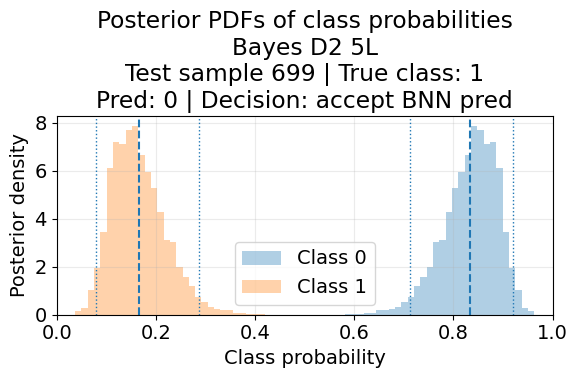

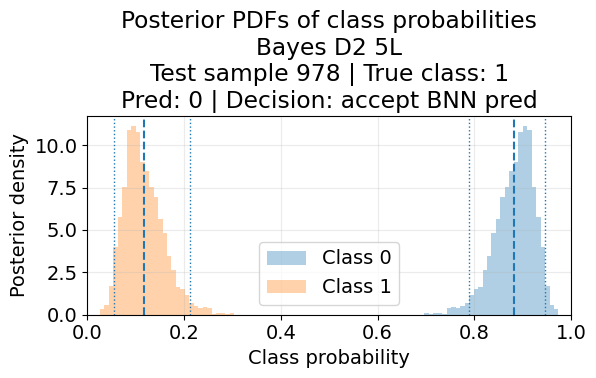

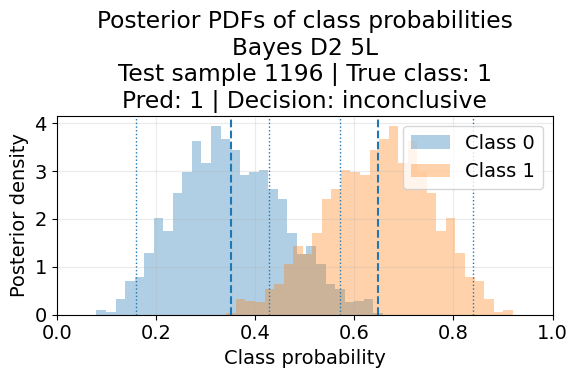

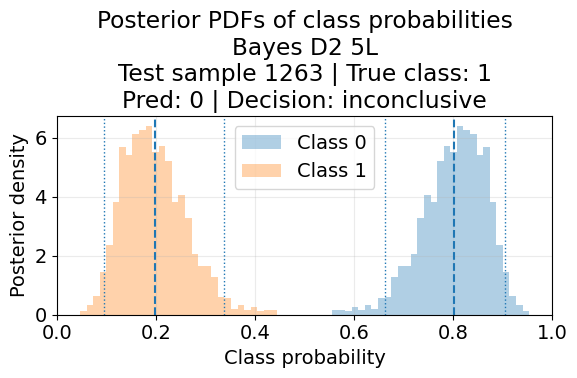

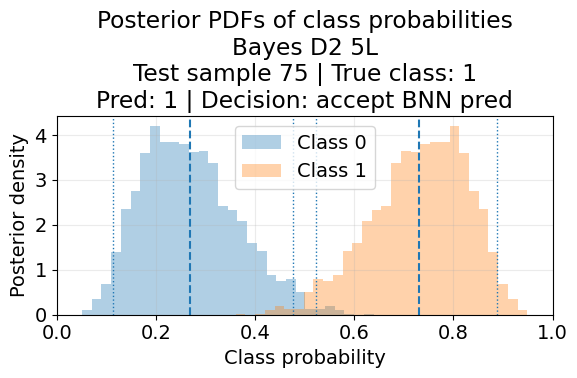

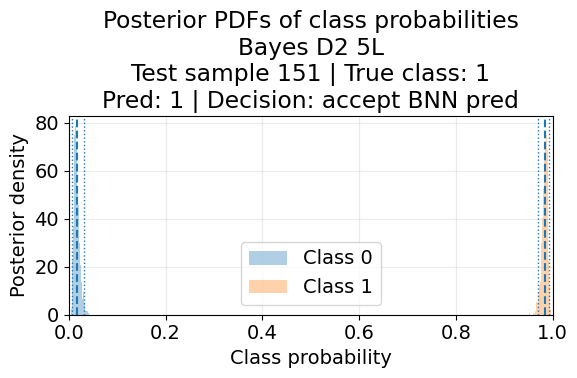

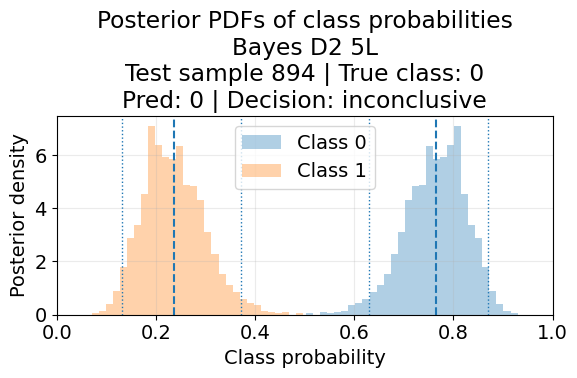

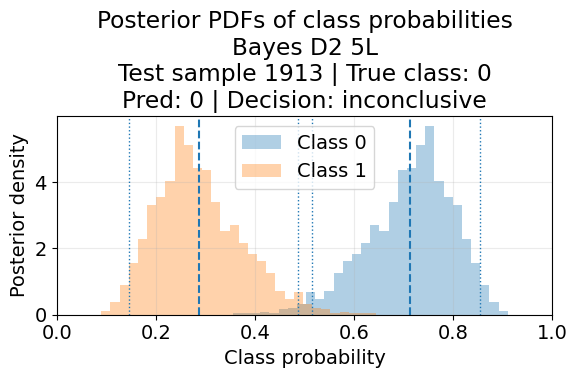

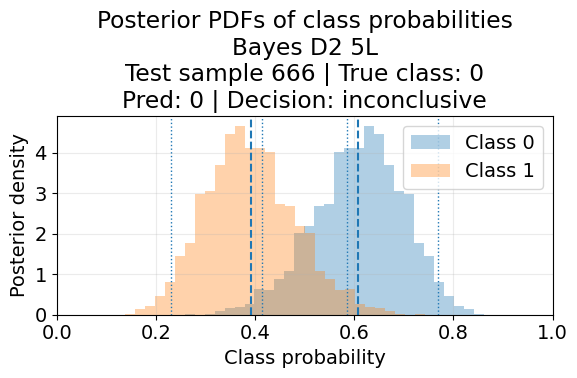

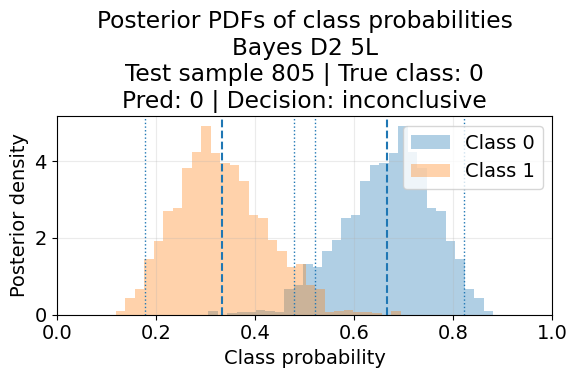

In [ ]:
# plot_random_class_probabilities_frequentist(probs=NN_results_10_ECG2['probs_mean'],num_classes=2,title='Freq D2 5L',out_path='PaperFigures',dpi=200,n_random=10,seed=92,true_labels=ytest)
plot_random_class_probabilities_bayesian(results=BNN_results_5_ECG2,posterior_probs=BNN_results_5_ECG2['probs_samples'],num_classes=2,title='Bayes D2 5L',out_path='PaperFigures',dpi=200,n_random=10,seed=92)

    # results: dict[str, np.ndarray],
    # posterior_probs: np.ndarray | None,
    # num_classes: int,
    # title: str,
    # out_path: Path,
    # dpi: int,
    # n_random: int,
    # # seed: int,

In [ ]:
print(np.shape(BNN_results_5_ECG2['probs_samples']))

(2000, 2000, 2)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def confusion_freq(ytest,yprob):
    conf_mat = np.zeros((2, 2), dtype=int)

    for i in range(len(ytest)):
        
        if yprob[i]<=0.5:
            # confidently class 0
            conf_mat[ytest[i], 0] += 1
        else:
            # interval crosses 0.5
            conf_mat[ytest[i], 1] += 1

    return conf_mat

def plot_confmatrix_freq(
    conf_mat,
    title="NN Decision Matrix",
    normalize=False,
    cmap="Blues",
    figsize=(7, 4.5),
):
    """
    Plot a 2x3 pseudo confusion matrix.

    Rows:
        0 -> true class 0
        1 -> true class 1

    Columns:
        0 -> predicted class 0 with confidence
        1 -> predicted class 1 with confidence
    """
    conf_mat = np.asarray(conf_mat)

    if conf_mat.shape != (2, 2):
        raise ValueError(f"Expected conf_mat shape (2, 2), got {conf_mat.shape}")

    display_mat = conf_mat.astype(float).copy()

    if normalize:
        row_sums = display_mat.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        display_mat = display_mat / row_sums

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(display_mat, cmap=cmap, aspect="auto")

    col_labels = [
        "Pred No SHD\n",
        "Pred SHD\n",
    ]
    row_labels = [
        "No SHD",
        "SHD",
    ]

    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_xticklabels(col_labels)
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(row_labels)

    ax.set_xlabel("Model decision")
    ax.set_ylabel("True class")
    ax.set_title(title)

    # Annotate cells
    thresh = display_mat.max() / 2.0 if display_mat.size > 0 else 0.0

    for i in range(conf_mat.shape[0]):
        for j in range(conf_mat.shape[1]):
            if normalize:
                text_str = f"{conf_mat[i, j]}\n({display_mat[i, j]:.1%})"
            else:
                text_str = f"{conf_mat[i, j]}"

            ax.text(
                j,
                i,
                text_str,
                ha="center",
                va="center",
                color="white" if display_mat[i, j] > thresh else "black",
                fontsize=11,
            )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Row-normalized proportion" if normalize else "Count")

    fig.tight_layout()
    plt.show()


def confusion_with_UQ(ytest, yprob,ci_noSHD_thresh,ci_SHD_thresh):
    conf_mat = np.zeros((2, 3), dtype=int)

    for i in range(len(ytest)):
        vals = np.asarray(yprob[:, i, 1], dtype=float)
        vals = vals[np.isfinite(vals)]

        if vals.size < 2:
            continue

        ci_low, ci_high = np.percentile(vals, [2.5, 97.5])

        if ci_high < ci_noSHD_thresh:
            # confidently class 0
            conf_mat[ytest[i], 0] += 1
        elif ci_low >= ci_SHD_thresh:
            # confidently class 1
            conf_mat[ytest[i], 2] += 1
        else:
            # interval crosses 0.5
            conf_mat[ytest[i], 1] += 1

    return conf_mat


def plot_uq_confusion_matrix(
    conf_mat,
    title="BNN Decision Matrix with Uncertainty",
    normalize=False,
    cmap="Blues",
    figsize=(7, 4.5),
):
    """
    Plot a 2x3 pseudo confusion matrix.

    Rows:
        0 -> true class 0
        1 -> true class 1

    Columns:
        0 -> predicted class 0 with confidence
        1 -> inconclusive
        2 -> predicted class 1 with confidence
    """
    conf_mat = np.asarray(conf_mat)

    if conf_mat.shape != (2, 3):
        raise ValueError(f"Expected conf_mat shape (2, 3), got {conf_mat.shape}")

    display_mat = conf_mat.astype(float).copy()

    if normalize:
        row_sums = display_mat.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        display_mat = display_mat / row_sums

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(display_mat, cmap=cmap, aspect="auto")

    col_labels = [
        "Pred No SHD\n(confident)",
        "Inconclusive",
        "Pred SHD\n(confident)",
    ]
    row_labels = [
        "No SHD",
        "SHD",
    ]

    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_xticklabels(col_labels)
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(row_labels)

    ax.set_xlabel("Model decision")
    ax.set_ylabel("True class")
    ax.set_title(title)

    # Annotate cells
    thresh = display_mat.max() / 2.0 if display_mat.size > 0 else 0.0

    for i in range(conf_mat.shape[0]):
        for j in range(conf_mat.shape[1]):
            if normalize:
                text_str = f"{conf_mat[i, j]}\n({display_mat[i, j]:.1%})"
            else:
                text_str = f"{conf_mat[i, j]}"

            ax.text(
                j,
                i,
                text_str,
                ha="center",
                va="center",
                color="white" if display_mat[i, j] > thresh else "black",
                fontsize=11,
            )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Row-normalized proportion" if normalize else "Count")

    fig.tight_layout()
    plt.show()


def summarize_uq_confusion_matrix(conf_mat):
    """
    Print a few useful summaries from the 2x3 matrix.
    """
    conf_mat = np.asarray(conf_mat)

    if conf_mat.shape != (2, 3):
        raise ValueError(f"Expected conf_mat shape (2, 3), got {conf_mat.shape}")

    tn_conf = conf_mat[0, 0]
    fp_conf = conf_mat[0, 2]
    tp_conf = conf_mat[1, 2]
    fn_conf = conf_mat[1, 0]

    inconclusive_0 = conf_mat[0, 1]
    inconclusive_1 = conf_mat[1, 1]

    total = conf_mat.sum()
    confident_total = tn_conf + fp_conf + tp_conf + fn_conf
    inconclusive_total = inconclusive_0 + inconclusive_1

    confident_accuracy = (
        (tn_conf + tp_conf) / confident_total if confident_total > 0 else np.nan
    )
    coverage = confident_total / total if total > 0 else np.nan
    inconclusive_rate = inconclusive_total / total if total > 0 else np.nan
    miss_disease_rate = fn_conf / total

    print("Decision matrix summaries")
    print("-------------------------")
    print(f"Total samples           : {total}")
    print(f"Confident predictions   : {confident_total}")
    print(f"Inconclusive predictions: {inconclusive_total}")
    print(f"Coverage                : {coverage:.3f}")
    print(f"Inconclusive rate       : {inconclusive_rate:.3f}")
    print(f"Confident accuracy      : {confident_accuracy:.3f}")
    print(f"% of those undiagnosed  : {fn_conf/total:.3f}")
    print(f"% SHD missed  : {miss_disease_rate:.3f}")
    

    print("\nCell breakdown")
    print(f"True 0 -> Pred 0 confident : {tn_conf}")
    print(f"True 0 -> Inconclusive     : {inconclusive_0}")
    print(f"True 0 -> Pred 1 confident : {fp_conf}")
    print(f"True 1 -> Pred 0 confident : {fn_conf}")
    print(f"True 1 -> Inconclusive     : {inconclusive_1}")
    print(f"True 1 -> Pred 1 confident : {tp_conf}")


    
def summarize_freq_confusion_matrix(conf_mat):
    """
    Print a few useful summaries from the 2x3 matrix.
    """
    conf_mat = np.asarray(conf_mat)


    tn_conf = conf_mat[0, 0]
    fp_conf = conf_mat[0, 1]
    tp_conf = conf_mat[1, 1]
    fn_conf = conf_mat[1, 0]


    total = conf_mat.sum()
    confident_total = tn_conf + fp_conf + tp_conf + fn_conf

    confident_accuracy = (
        (tn_conf + tp_conf) / confident_total if confident_total > 0 else np.nan
    )
    coverage = confident_total / total if total > 0 else np.nan
    miss_disease_rate = fn_conf / total

    print("Decision matrix summaries")
    print("-------------------------")
    print(f"Total samples           : {total}")
    print(f"Confident predictions   : {confident_total}")
    print(f"Coverage                : {coverage:.3f}")
    print(f"Confident accuracy      : {confident_accuracy:.3f}")
    print(f"% of those undiagnosed  : {fn_conf/total:.3f}")
    print(f"% SHD missed  : {miss_disease_rate:.3f}")
    

    print("\nCell breakdown")
    print(f"True 0 -> Pred 0 confident : {tn_conf}")
    print(f"True 0 -> Pred 1 confident : {fp_conf}")
    print(f"True 1 -> Pred 0 confident : {fn_conf}")
    print(f"True 1 -> Pred 1 confident : {tp_conf}")


# -------------------------------
# Example usage
# -------------------------------
# y_test: shape (N,)
# probs_samples: shape (S, N, 2)

# conf_mat = confusion_with_UQ(y_test, probs_samples)
# print(conf_mat)

# Raw counts
# plot_uq_confusion_matrix(
#     conf_mat,
#     title="BNN Decision Matrix",
#     normalize=False,
# )

# Row-normalized view
# plot_uq_confusion_matrix(
#     conf_mat,
#     title="BNN Decision Matrix (row-normalized)",
#     normalize=True,
# )

# Summary statistics
# summarize_uq_confusion_matrix(conf_mat)

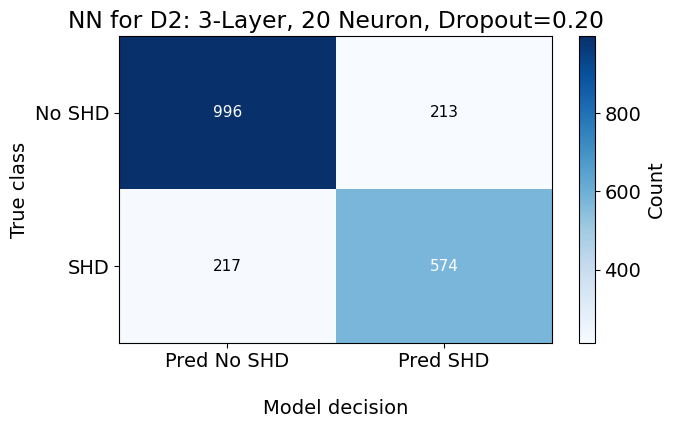

Decision matrix summaries
-------------------------
Total samples           : 2000
Confident predictions   : 2000
Coverage                : 1.000
Confident accuracy      : 0.785
% of those undiagnosed  : 0.108
% SHD missed  : 0.108

Cell breakdown
True 0 -> Pred 0 confident : 996
True 0 -> Pred 1 confident : 213
True 1 -> Pred 0 confident : 217
True 1 -> Pred 1 confident : 574


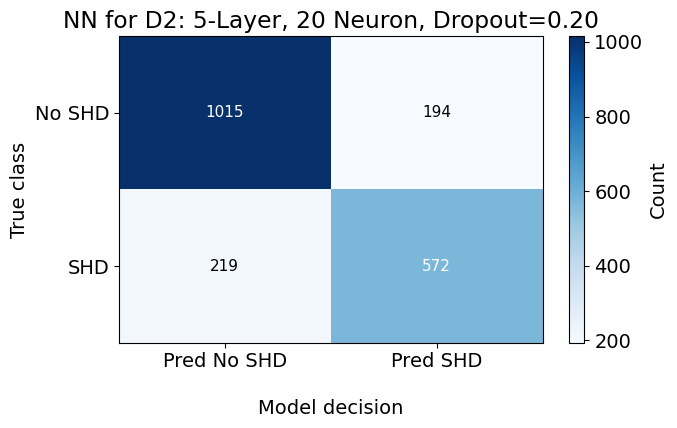

Decision matrix summaries
-------------------------
Total samples           : 2000
Confident predictions   : 2000
Coverage                : 1.000
Confident accuracy      : 0.793
% of those undiagnosed  : 0.110
% SHD missed  : 0.110

Cell breakdown
True 0 -> Pred 0 confident : 1015
True 0 -> Pred 1 confident : 194
True 1 -> Pred 0 confident : 219
True 1 -> Pred 1 confident : 572


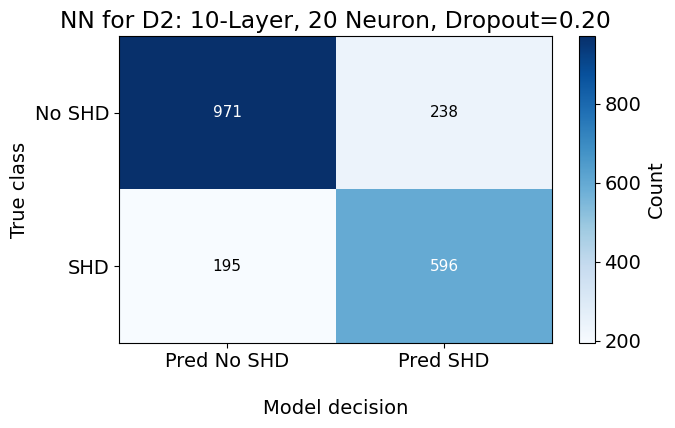

Decision matrix summaries
-------------------------
Total samples           : 2000
Confident predictions   : 2000
Coverage                : 1.000
Confident accuracy      : 0.783
% of those undiagnosed  : 0.098
% SHD missed  : 0.098

Cell breakdown
True 0 -> Pred 0 confident : 971
True 0 -> Pred 1 confident : 238
True 1 -> Pred 0 confident : 195
True 1 -> Pred 1 confident : 596


In [ ]:
conf_NN_3 = confusion_freq(ytest=ytest,yprob=NN_results_3_ECG2['probs_mean'])
plot_confmatrix_freq(conf_mat=conf_NN_3,title='NN for D2: 3-Layer, 20 Neuron, Dropout=0.20')
summarize_freq_confusion_matrix(conf_mat=conf_NN_3)

conf_NN_5 = confusion_freq(ytest=ytest,yprob=NN_results_5_ECG2['probs_mean'])
plot_confmatrix_freq(conf_mat=conf_NN_5,title='NN for D2: 5-Layer, 20 Neuron, Dropout=0.20')
summarize_freq_confusion_matrix(conf_mat=conf_NN_5)


conf_NN_10 = confusion_freq(ytest=ytest,yprob=NN_results_10_ECG2['probs_mean'])
plot_confmatrix_freq(conf_mat=conf_NN_10,title='NN for D2: 10-Layer, 20 Neuron, Dropout=0.20')
summarize_freq_confusion_matrix(conf_mat=conf_NN_10)



<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\colebanm\AppData\Local\Temp\ipykernel_57672\2606015016.py:2: SyntaxWarning: invalid escape sequence '\s'
  plot_confmatrix_freq(conf_mat=conf_BNN_3,title='BNN for D2: 3-Layer, 20 Neuron, $\sigma^2=0.25$')
C:\Users\colebanm\AppData\Local\Temp\ipykernel_57672\2606015016.py:6: SyntaxWarning: invalid escape sequence '\s'
  plot_confmatrix_freq(conf_mat=conf_BNN_5,title='BNN for D2: 5-Layer, 20 Neuron, $\sigma^2=0.25$')
C:\Users\colebanm\AppData\Local\Temp\ipykernel_57672\2606015016.py:11: SyntaxWarning: invalid escape sequence '\s'
  plot_confmatrix_freq(conf_mat=conf_BNN_10,title='BNN for D2: 10-Layer, 20 Neuron, $\sigma^2=0.25$')


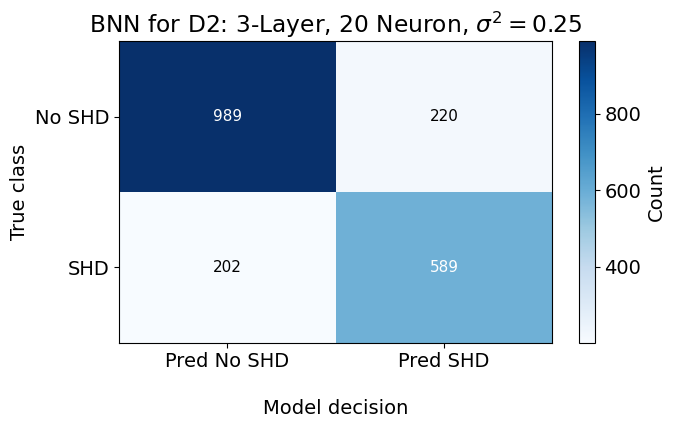

Decision matrix summaries
-------------------------
Total samples           : 2000
Confident predictions   : 2000
Coverage                : 1.000
Confident accuracy      : 0.789
% of those undiagnosed  : 0.101
% SHD missed  : 0.101

Cell breakdown
True 0 -> Pred 0 confident : 989
True 0 -> Pred 1 confident : 220
True 1 -> Pred 0 confident : 202
True 1 -> Pred 1 confident : 589


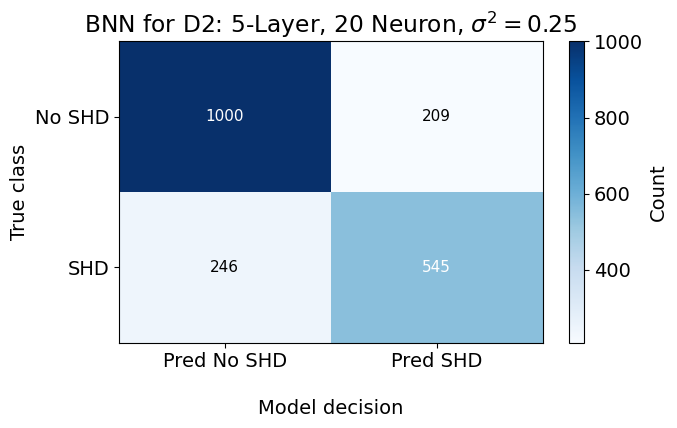

Decision matrix summaries
-------------------------
Total samples           : 2000
Confident predictions   : 2000
Coverage                : 1.000
Confident accuracy      : 0.772
% of those undiagnosed  : 0.123
% SHD missed  : 0.123

Cell breakdown
True 0 -> Pred 0 confident : 1000
True 0 -> Pred 1 confident : 209
True 1 -> Pred 0 confident : 246
True 1 -> Pred 1 confident : 545


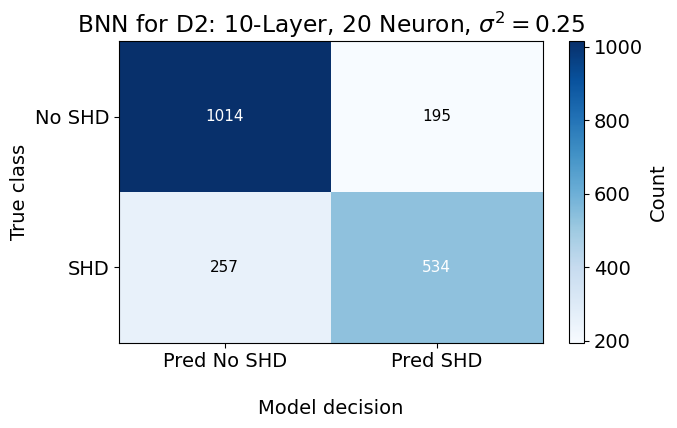

Decision matrix summaries
-------------------------
Total samples           : 2000
Confident predictions   : 2000
Coverage                : 1.000
Confident accuracy      : 0.774
% of those undiagnosed  : 0.129
% SHD missed  : 0.129

Cell breakdown
True 0 -> Pred 0 confident : 1014
True 0 -> Pred 1 confident : 195
True 1 -> Pred 0 confident : 257
True 1 -> Pred 1 confident : 534


In [ ]:
conf_BNN_3 = confusion_freq(ytest=ytest,yprob=BNN_results_3_ECG2['probs_mean'][:,1])
plot_confmatrix_freq(conf_mat=conf_BNN_3,title='BNN for D2: 3-Layer, 20 Neuron, $\sigma^2=0.25$')
summarize_freq_confusion_matrix(conf_mat=conf_BNN_3)

conf_BNN_5 = confusion_freq(ytest=ytest,yprob=BNN_results_5_ECG2['probs_mean'][:,1])
plot_confmatrix_freq(conf_mat=conf_BNN_5,title='BNN for D2: 5-Layer, 20 Neuron, $\sigma^2=0.25$')
summarize_freq_confusion_matrix(conf_mat=conf_BNN_5)


conf_BNN_10 = confusion_freq(ytest=ytest,yprob=BNN_results_10_ECG2['probs_mean'][:,1])
plot_confmatrix_freq(conf_mat=conf_BNN_10,title='BNN for D2: 10-Layer, 20 Neuron, $\sigma^2=0.25$')
summarize_freq_confusion_matrix(conf_mat=conf_BNN_10)


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
C:\Users\colebanm\AppData\Local\Temp\ipykernel_57672\2343538776.py:2: SyntaxWarning: invalid escape sequence '\s'
  plot_uq_confusion_matrix(conf_mat=conf_BNN_3,title='BNN for D2: 3-Layer, 10 Neuron, $\sigma^2=0.25$')
C:\Users\colebanm\AppData\Local\Temp\ipykernel_57672\2343538776.py:5: SyntaxWarning: invalid escape sequence '\s'
  plot_uq_confusion_matrix(conf_mat=conf_BNN_5,title='BNN for D2: 5-Layer, 20 Neuron, $\sigma^2=0.10$')
C:\Users\colebanm\AppData\Local\Temp\ipykernel_57672\2343538776.py:8: SyntaxWarning: invalid escape sequence '\s'
  plot_uq_confusion_matrix(conf_mat=conf_BNN_10,title='BNN for D2: 10-Layer, 20 Neuron, $\sigma^2=0.10$')


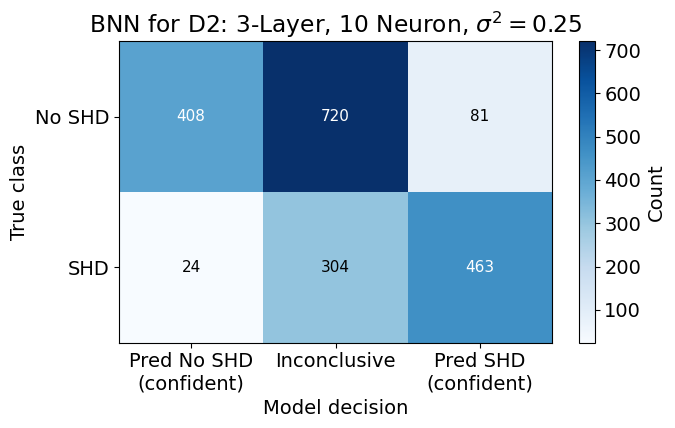

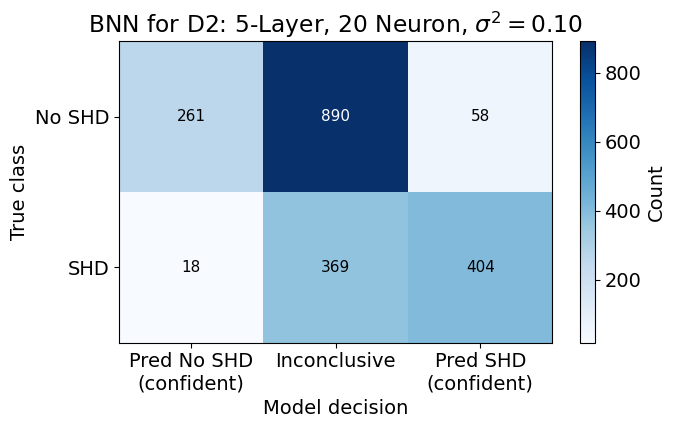

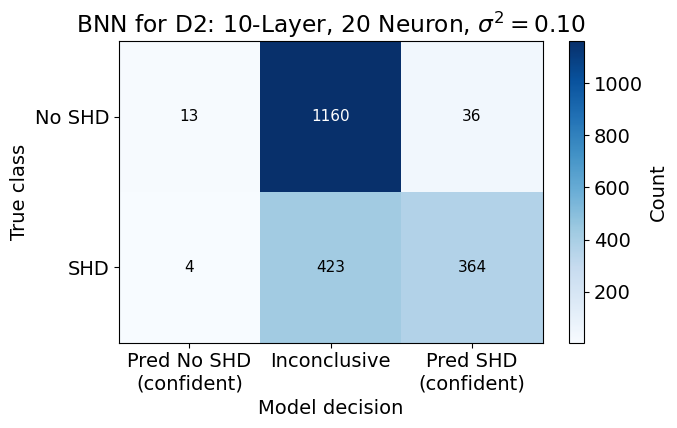


BNN 3 Results

Decision matrix summaries
-------------------------
Total samples           : 2000
Confident predictions   : 976
Inconclusive predictions: 1024
Coverage                : 0.488
Inconclusive rate       : 0.512
Confident accuracy      : 0.892
% of those undiagnosed  : 0.012
% SHD missed  : 0.012

Cell breakdown
True 0 -> Pred 0 confident : 408
True 0 -> Inconclusive     : 720
True 0 -> Pred 1 confident : 81
True 1 -> Pred 0 confident : 24
True 1 -> Inconclusive     : 304
True 1 -> Pred 1 confident : 463

BNN 5 Results

Decision matrix summaries
-------------------------
Total samples           : 2000
Confident predictions   : 741
Inconclusive predictions: 1259
Coverage                : 0.370
Inconclusive rate       : 0.629
Confident accuracy      : 0.897
% of those undiagnosed  : 0.009
% SHD missed  : 0.009

Cell breakdown
True 0 -> Pred 0 confident : 261
True 0 -> Inconclusive     : 890
True 0 -> Pred 1 confident : 58
True 1 -> Pred 0 confident : 18
True 1 -> Inconclusive

In [ ]:
conf_BNN_3 = confusion_with_UQ(ytest=ytest,yprob=BNN_results_3_ECG2['probs_samples'],ci_noSHD_thresh=0.3,ci_SHD_thresh=0.5)
plot_uq_confusion_matrix(conf_mat=conf_BNN_3,title='BNN for D2: 3-Layer, 10 Neuron, $\sigma^2=0.25$')

conf_BNN_5 = confusion_with_UQ(ytest=ytest,yprob=BNN_results_5_ECG2['probs_samples'],ci_noSHD_thresh=0.3,ci_SHD_thresh=0.5)
plot_uq_confusion_matrix(conf_mat=conf_BNN_5,title='BNN for D2: 5-Layer, 20 Neuron, $\sigma^2=0.10$')

conf_BNN_10 = confusion_with_UQ(ytest=ytest,yprob=BNN_results_10_ECG2['probs_samples'],ci_noSHD_thresh=0.3,ci_SHD_thresh=0.5)
plot_uq_confusion_matrix(conf_mat=conf_BNN_10,title='BNN for D2: 10-Layer, 20 Neuron, $\sigma^2=0.10$')

print('\nBNN 3 Results\n')
summarize_uq_confusion_matrix(conf_mat=conf_BNN_3)
print('\nBNN 5 Results\n')
summarize_uq_confusion_matrix(conf_mat=conf_BNN_5)
print('\nBNN 10 Results\n')
summarize_uq_confusion_matrix(conf_mat=conf_BNN_10)

In [ ]:
63/2000

0.0315